
# Unicauca Network Traffic Classification — EDA, Feature Engineering & Multiclass ML

**Dataset:** `Dataset-Unicauca-Version2-87Atts.csv` from Juan Sebastián Rojas' Kaggle dataset, *IP Network Traffic Flows Labeled with 75 Apps*.

## Project goals

1. Build a modeling dataset with the application label removed from the predictors.
2. Train and compare multiple multiclass classification algorithms.
3. Compare actual labels with predicted labels at the observation level.
4. Explore unsupervised clustering.
5. Perform EDA to understand distributions, relationships, imbalance, outliers, and application-specific network signatures.
6. Engineer meaningful network-flow features.
7. Establish Logistic Regression as a reproducible baseline for the next module.
8. Save tables and visualizations that can be reused in the final presentation.

> **Important:** The source CSV is about 1.77 GB, so this notebook is deliberately designed around chunked reading and a configurable stratified modeling sample. Full-data profiling uses chunks; computationally expensive ML does not require loading the entire CSV into RAM.



## Research question

> **To what extent can network-flow characteristics distinguish among application types, and which characteristics provide the greatest discriminatory information?**

### Supporting questions

- Are application classes balanced?
- Which network-flow variables differ most strongly among applications?
- Are there strongly correlated or redundant variables?
- Do applications form visible groups in reduced-dimensional space?
- Which baseline/classification algorithms perform best?
- Which application classes are most frequently confused?
- Does feature engineering improve the baseline?


In [1]:

# Install once if necessary:
# %pip install pandas numpy matplotlib seaborn scikit-learn scipy pyarrow kagglehub joblib openpyxl

import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    adjusted_rand_score, normalized_mutual_info_score, silhouette_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
DATA_DIR = Path("/Users/venky.natham/github_projects/berkeley/capstone_project/data")
OUTPUT_DIR = Path("/Users/venky.natham/github_projects/berkeley/capstone_project/outputs")
FIG_DIR = OUTPUT_DIR / "figures"

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())


Output directory: /Users/venky.natham/github_projects/berkeley/capstone_project/outputs



## 1. Obtain the dataset

The Kaggle source is:

`jsrojas/ip-network-traffic-flows-labeled-with-87-apps`

If Kaggle credentials are configured, the following cell can download the dataset programmatically. Otherwise, download the CSV from Kaggle and place it under `data/`.

The expected file is:

`data/Dataset-Unicauca-Version2-87Atts.csv`


In [2]:

# Option A: download using KaggleHub (recommended in Kaggle/Colab environments)
# Uncomment if your environment has Kaggle credentials configured.

# import kagglehub
# path = kagglehub.dataset_download("jsrojas/ip-network-traffic-flows-labeled-with-87-apps")
# print("Downloaded dataset directory:", path)

# Option B: Kaggle CLI
# !kaggle datasets download -d jsrojas/ip-network-traffic-flows-labeled-with-87-apps -p data --unzip

DATA_PATH = DATA_DIR / "Dataset-Unicauca-Version2-87Atts.csv"

if DATA_PATH.exists():
    print(f"Found: {DATA_PATH}")
else:
    print("CSV not found yet. Download it from Kaggle and place it at:")
    print(DATA_PATH)


Found: /Users/venky.natham/github_projects/berkeley/capstone_project/data/Dataset-Unicauca-Version2-87Atts.csv



## 2. Discover the schema without loading the whole file

We first inspect the header and a small sample. This is important because the dataset has multiple protocol/label-related fields and we do not want to accidentally use the target or a leakage-prone field as a predictor.


In [3]:

# Read only a small sample
sample = pd.read_csv(DATA_PATH, nrows=10000, low_memory=False)

print("Sample shape:", sample.shape)
print("\nColumns:")
for i, c in enumerate(sample.columns, 1):
    print(f"{i:02d}. {c}")

display(sample.head())
display(sample.dtypes.to_frame("dtype"))


Sample shape: (10000, 87)

Columns:
01. Flow.ID
02. Source.IP
03. Source.Port
04. Destination.IP
05. Destination.Port
06. Protocol
07. Timestamp
08. Flow.Duration
09. Total.Fwd.Packets
10. Total.Backward.Packets
11. Total.Length.of.Fwd.Packets
12. Total.Length.of.Bwd.Packets
13. Fwd.Packet.Length.Max
14. Fwd.Packet.Length.Min
15. Fwd.Packet.Length.Mean
16. Fwd.Packet.Length.Std
17. Bwd.Packet.Length.Max
18. Bwd.Packet.Length.Min
19. Bwd.Packet.Length.Mean
20. Bwd.Packet.Length.Std
21. Flow.Bytes.s
22. Flow.Packets.s
23. Flow.IAT.Mean
24. Flow.IAT.Std
25. Flow.IAT.Max
26. Flow.IAT.Min
27. Fwd.IAT.Total
28. Fwd.IAT.Mean
29. Fwd.IAT.Std
30. Fwd.IAT.Max
31. Fwd.IAT.Min
32. Bwd.IAT.Total
33. Bwd.IAT.Mean
34. Bwd.IAT.Std
35. Bwd.IAT.Max
36. Bwd.IAT.Min
37. Fwd.PSH.Flags
38. Bwd.PSH.Flags
39. Fwd.URG.Flags
40. Bwd.URG.Flags
41. Fwd.Header.Length
42. Bwd.Header.Length
43. Fwd.Packets.s
44. Bwd.Packets.s
45. Min.Packet.Length
46. Max.Packet.Length
47. Packet.Length.Mean
48. Packet.Length.Std
49

,Flow.ID,Source.IP,Source.Port,Destination.IP,Destination.Port,Protocol,Timestamp,Flow.Duration,Total.Fwd.Packets,Total.Backward.Packets,...,Active.Std,Active.Max,Active.Min,Idle.Mean,Idle.Std,Idle.Max,Idle.Min,Label,L7Protocol,ProtocolName
0,172.19.1.46-10.200.7.7-52422-3128-6,172.19.1.46,52422,10.200.7.7,3128,6,26/04/201711:11:17,45523,22,55,...,0.0,0,0,0.0,0.0,0,0,BENIGN,131,HTTP_PROXY
1,172.19.1.46-10.200.7.7-52422-3128-6,10.200.7.7,3128,172.19.1.46,52422,6,26/04/201711:11:17,1,2,0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,131,HTTP_PROXY
2,10.200.7.217-50.31.185.39-38848-80-6,50.31.185.39,80,10.200.7.217,38848,6,26/04/201711:11:17,1,3,0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,7,HTTP
3,10.200.7.217-50.31.185.39-38848-80-6,50.31.185.39,80,10.200.7.217,38848,6,26/04/201711:11:17,217,1,3,...,0.0,0,0,0.0,0.0,0,0,BENIGN,7,HTTP
4,192.168.72.43-10.200.7.7-55961-3128-6,192.168.72.43,55961,10.200.7.7,3128,6,26/04/201711:11:17,78068,5,0,...,0.0,0,0,0.0,0.0,0,0,BENIGN,131,HTTP_PROXY


,dtype
Flow.ID,str
Source.IP,str
Source.Port,int64
Destination.IP,str
Destination.Port,int64
...,...
Idle.Max,int64
Idle.Min,int64
Label,str
L7Protocol,int64


In [4]:

# Candidate label columns — inspect before choosing the final target.
label_candidates = [
    c for c in sample.columns
    if any(term in c.lower() for term in ["label", "app", "protocol", "l7"])
]

print("Candidate label/protocol fields:")
print(label_candidates)

# Set this after inspecting the output. For many versions of this dataset,
# L7Protocol / ProtocolName are label-related fields.
TARGET = "L7Protocol"

# Example:
# TARGET = "L7Protocol"
# or
# TARGET = "ProtocolName"

if TARGET is None:
    print("\nACTION: Set TARGET to the application label column after inspecting the schema.")


Candidate label/protocol fields:
['Protocol', 'Label', 'L7Protocol', 'ProtocolName']



## 3. Chunked full-data profiling

The full CSV is too large for a naive `pd.read_csv()` call on many machines. The following helper functions process the dataset in chunks.

We calculate:

- total rows
- missing values
- numeric summaries
- class counts
- approximate duplicate counts
- unique values for low-cardinality categorical fields

The class distribution is especially important because the dataset contains many application classes.


In [5]:

CHUNK_SIZE = 100_000

def profile_csv(path, target, chunksize=CHUNK_SIZE):
    total_rows = 0
    missing = None
    numeric_sum = None
    numeric_sumsq = None
    numeric_min = None
    numeric_max = None
    class_counts = {}
    sample_parts = []

    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
        total_rows += len(chunk)

        if len(sample_parts) < 5:
            sample_parts.append(chunk.head(2000))

        miss = chunk.isna().sum()
        missing = miss if missing is None else missing.add(miss, fill_value=0)

        num = chunk.select_dtypes(include=np.number)
        if not num.empty:
            s = num.sum()
            ss = (num.astype("float64") ** 2).sum()
            mn = num.min()
            mx = num.max()

            numeric_sum = s if numeric_sum is None else numeric_sum.add(s, fill_value=0)
            numeric_sumsq = ss if numeric_sumsq is None else numeric_sumsq.add(ss, fill_value=0)
            numeric_min = mn if numeric_min is None else pd.concat([numeric_min, mn], axis=1).min(axis=1)
            numeric_max = mx if numeric_max is None else pd.concat([numeric_max, mx], axis=1).max(axis=1)

        if target in chunk.columns:
            counts = chunk[target].value_counts(dropna=False)
            for k, v in counts.items():
                class_counts[k] = class_counts.get(k, 0) + int(v)

    missing_pct = (missing / total_rows * 100).sort_values(ascending=False)

    return {
        "rows": total_rows,
        "missing": missing.sort_values(ascending=False),
        "missing_pct": missing_pct,
        "class_counts": pd.Series(class_counts).sort_values(ascending=False),
        "sample": pd.concat(sample_parts, ignore_index=True)
    }

if TARGET is not None:
    profile = profile_csv(DATA_PATH, TARGET)
    print("Total rows:", profile["rows"])
    display(profile["missing_pct"].head(20).to_frame("missing_pct"))
    display(profile["class_counts"].head(30).to_frame("count"))


Total rows: 3577296


,missing_pct
Flow.ID,0.0
CWE.Flag.Count,0.0
Fwd.Avg.Packets.Bulk,0.0
Fwd.Avg.Bytes.Bulk,0.0
Fwd.Header.Length.1,0.0
Avg.Bwd.Segment.Size,0.0
Avg.Fwd.Segment.Size,0.0
Average.Packet.Size,0.0
Down.Up.Ratio,0.0
ECE.Flag.Count,0.0


,count
126,959110
7,683734
131,623210
91,404883
130,317526
124,170781
178,86875
212,54710
122,40260
147,34471


## 4. Class distribution

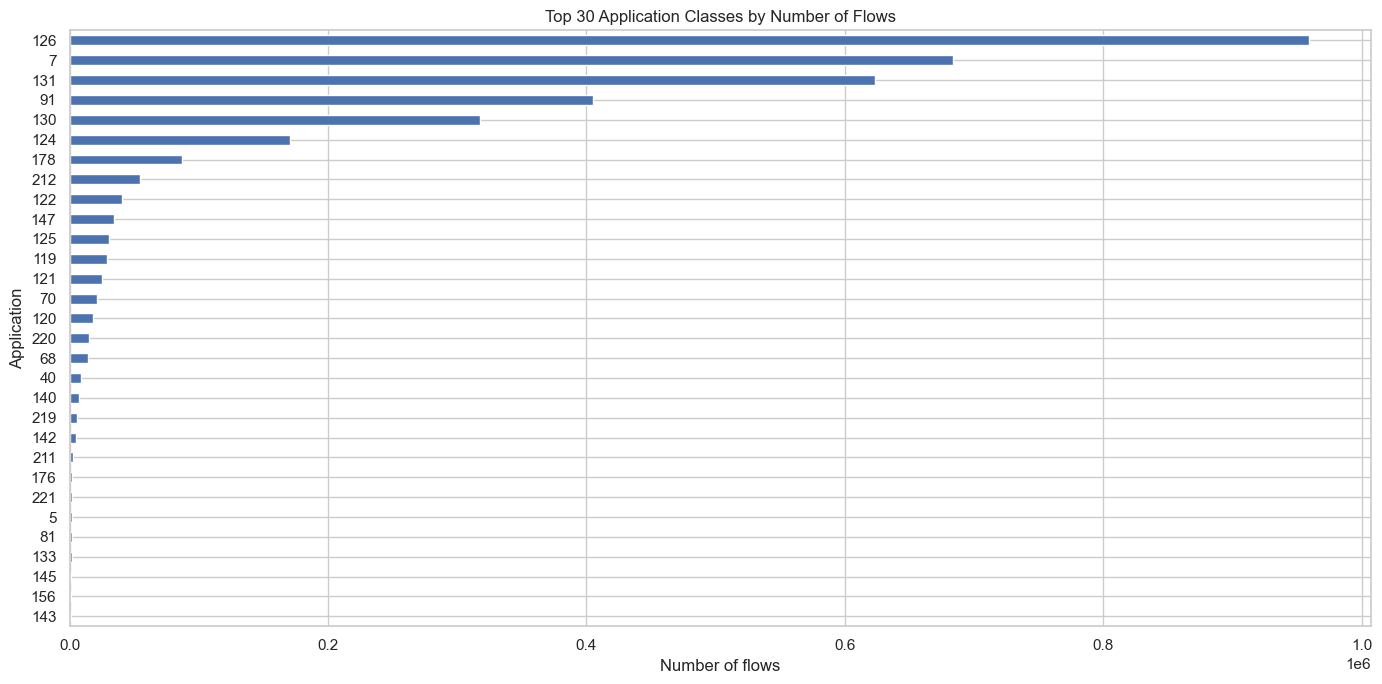

Number of classes: 78
Largest/smallest class ratio: 959,110.0x


In [6]:

if TARGET is not None:
    class_counts = profile["class_counts"]

    plt.figure(figsize=(14, 7))
    class_counts.head(30).sort_values().plot(kind="barh")
    plt.title("Top 30 Application Classes by Number of Flows")
    plt.xlabel("Number of flows")
    plt.ylabel("Application")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "01_top30_class_distribution.png", dpi=180, bbox_inches="tight")
    plt.show()

    imbalance_ratio = class_counts.max() / class_counts.min()
    print(f"Number of classes: {class_counts.size}")
    print(f"Largest/smallest class ratio: {imbalance_ratio:,.1f}x")



## 5. Build a modeling sample

For ML, we use a **stratified sample** so that smaller application classes are represented. This is separate from full-data EDA.

The sample size can be increased if your machine has sufficient RAM/CPU.

A useful starting point is 300,000–500,000 observations.


In [7]:
MODEL_SAMPLE_SIZE = 300_000
# We need enough observations in every retained class for a stratified 80/20 split.
MIN_SAMPLES_PER_CLASS = 20


def stratified_sample_csv(path, target, n_rows=MODEL_SAMPLE_SIZE,
                          min_samples_per_class=MIN_SAMPLES_PER_CLASS,
                          chunksize=CHUNK_SIZE, random_state=RANDOM_STATE):
    """Create a proportional sample while retaining only classes with enough rows."""
    # Pass 1: exact class counts.
    counts_dict = {}
    total = 0
    for chunk in pd.read_csv(path, usecols=[target], chunksize=chunksize, low_memory=False):
        total += len(chunk)
        for cls, count in chunk[target].value_counts(dropna=False).items():
            counts_dict[cls] = counts_dict.get(cls, 0) + int(count)

    counts = pd.Series(counts_dict, dtype="int64").sort_index()
    eligible = counts[counts >= min_samples_per_class]
    excluded = counts[counts < min_samples_per_class]

    print(f"Original dataset rows: {total:,}")
    print(f"Original number of classes: {len(counts)}")
    print(f"Classes retained (>= {min_samples_per_class} rows): {len(eligible)}")
    print(f"Rare classes excluded from modeling: {len(excluded)}")
    if len(excluded):
        print("Excluded class counts:")
        display(excluded.sort_values().to_frame("count"))

    if len(eligible) < 2:
        raise ValueError("Fewer than two classes have enough observations for modeling.")

    # Never request more rows than are available in eligible classes.
    eligible_total = int(eligible.sum())
    n_rows = min(int(n_rows), eligible_total)
    minimum_total = len(eligible) * min_samples_per_class
    if n_rows < minimum_total:
        raise ValueError(
            f"MODEL_SAMPLE_SIZE={n_rows:,} is too small for {len(eligible)} classes "
            f"with MIN_SAMPLES_PER_CLASS={min_samples_per_class}."
        )

    # Start by guaranteeing the minimum in every eligible class.
    desired = pd.Series(min_samples_per_class, index=eligible.index, dtype="int64")
    remaining = n_rows - int(desired.sum())

    # Allocate remaining observations approximately proportionally to class size.
    if remaining > 0:
        weights = (eligible - desired).clip(lower=0)
        if weights.sum() > 0:
            raw = remaining * weights / weights.sum()
            desired += np.floor(raw).astype("int64")
            leftover = n_rows - int(desired.sum())
            remainders = (raw - np.floor(raw)).sort_values(ascending=False)
            for cls in remainders.index:
                if leftover == 0:
                    break
                if desired[cls] < eligible[cls]:
                    desired[cls] += 1
                    leftover -= 1

    # Safety adjustment in case rounding/caps leave rows unallocated.
    while desired.sum() < n_rows:
        capacity = eligible - desired
        capacity = capacity[capacity > 0]
        if capacity.empty:
            break
        desired[capacity.idxmax()] += 1

    if int(desired.sum()) != n_rows:
        raise RuntimeError(f"Could not allocate exactly {n_rows:,} rows; got {desired.sum():,}.")

    print(f"Requested modeling sample: {n_rows:,}")
    print(f"Smallest requested class sample: {desired.min()}")

    # Pass 2: reservoir sample separately within each eligible class.
    rng = np.random.default_rng(random_state)
    reservoirs = {cls: [] for cls in desired.index}
    seen = {cls: 0 for cls in desired.index}

    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
        chunk = chunk[chunk[target].isin(desired.index)]
        for cls, group in chunk.groupby(target, sort=False):
            k = int(desired[cls])
            for row in group.to_dict("records"):
                seen[cls] += 1
                if len(reservoirs[cls]) < k:
                    reservoirs[cls].append(row)
                else:
                    j = rng.integers(0, seen[cls])
                    if j < k:
                        reservoirs[cls][j] = row

    sampled = pd.DataFrame([r for rows in reservoirs.values() for r in rows])
    sampled = sampled.sample(frac=1, random_state=random_state).reset_index(drop=True)

    actual_counts = sampled[target].value_counts()
    print(f"Actual modeling sample shape: {sampled.shape}")
    print(f"Smallest actual class: {actual_counts.min()}")
    assert actual_counts.min() >= min_samples_per_class
    return sampled


if TARGET is not None:
    model_df = stratified_sample_csv(DATA_PATH, TARGET)
    print("Modeling sample shape:", model_df.shape)
    print("Classes used for modeling:", model_df[TARGET].nunique())
    display(model_df[TARGET].value_counts().sort_index().to_frame("count"))


Original dataset rows: 3,577,296
Original number of classes: 78
Classes retained (>= 20 rows): 55
Rare classes excluded from modeling: 23
Excluded class counts:


,count
11,1
172,1
202,1
48,2
213,3
14,4
159,4
85,5
200,5
146,5


Requested modeling sample: 300,000
Smallest requested class sample: 20
Actual modeling sample shape: (300000, 87)
Smallest actual class: 20
Modeling sample shape: (300000, 87)
Classes used for modeling: 55


,count
L7Protocol,
1,20
5,160
7,57168
9,30
36,26
40,736
60,61
64,90
67,22



## 6. Data cleaning and leakage review

We do not automatically use every column.

Potentially problematic fields include:

- source/destination IP addresses
- raw flow identifiers
- timestamps
- explicit application/protocol fields
- duplicate identifiers
- fields derived directly from the label

For the baseline, we prefer **flow-statistical features** over explicit application identifiers. The exact exclusions should be documented in the final report.


In [9]:

if TARGET is not None:
    print("All columns:")
    print(model_df.columns.tolist())

    # Candidate identifiers / leakage-prone fields.
    leakage_terms = [
        "flow.id", "source.ip", "destination.ip",
        "timestamp", "label", "app", "application",
        "protocolname", "l7protocol"
    ]

    suspected = [
        c for c in model_df.columns
        if any(term in c.lower() for term in leakage_terms)
    ]

    print("\nPotentially excluded / reviewed columns:")
    print(suspected)


All columns:
['Flow.ID', 'Source.IP', 'Source.Port', 'Destination.IP', 'Destination.Port', 'Protocol', 'Timestamp', 'Flow.Duration', 'Total.Fwd.Packets', 'Total.Backward.Packets', 'Total.Length.of.Fwd.Packets', 'Total.Length.of.Bwd.Packets', 'Fwd.Packet.Length.Max', 'Fwd.Packet.Length.Min', 'Fwd.Packet.Length.Mean', 'Fwd.Packet.Length.Std', 'Bwd.Packet.Length.Max', 'Bwd.Packet.Length.Min', 'Bwd.Packet.Length.Mean', 'Bwd.Packet.Length.Std', 'Flow.Bytes.s', 'Flow.Packets.s', 'Flow.IAT.Mean', 'Flow.IAT.Std', 'Flow.IAT.Max', 'Flow.IAT.Min', 'Fwd.IAT.Total', 'Fwd.IAT.Mean', 'Fwd.IAT.Std', 'Fwd.IAT.Max', 'Fwd.IAT.Min', 'Bwd.IAT.Total', 'Bwd.IAT.Mean', 'Bwd.IAT.Std', 'Bwd.IAT.Max', 'Bwd.IAT.Min', 'Fwd.PSH.Flags', 'Bwd.PSH.Flags', 'Fwd.URG.Flags', 'Bwd.URG.Flags', 'Fwd.Header.Length', 'Bwd.Header.Length', 'Fwd.Packets.s', 'Bwd.Packets.s', 'Min.Packet.Length', 'Max.Packet.Length', 'Packet.Length.Mean', 'Packet.Length.Std', 'Packet.Length.Variance', 'FIN.Flag.Count', 'SYN.Flag.Count', 'RST.Flag.

In [10]:
# Explicitly remove identifiers and label-equivalent fields from the predictors.
# TARGET is kept separately as y.
EXCLUDE_COLUMNS = [
    "Flow.ID",
    "Source.IP",
    "Destination.IP",
    "Timestamp",
    "Label",
    "ProtocolName",
]

if TARGET is not None:
    EXCLUDE_COLUMNS = list(dict.fromkeys(EXCLUDE_COLUMNS + [TARGET]))
    X_raw = model_df.drop(columns=EXCLUDE_COLUMNS, errors="ignore").copy()
    y = model_df[TARGET].copy()

    print("X shape:", X_raw.shape)
    print("y shape:", y.shape)
    print("Classes in y:", y.nunique())
    print("Minimum class count in y:", y.value_counts().min())
    print("Remaining object columns:", X_raw.select_dtypes(include=["object"]).columns.tolist())


X shape: (300000, 80)
y shape: (300000,)
Classes in y: 55
Minimum class count in y: 20
Remaining object columns: []



## 7. Feature engineering

The following function creates ratio/rate features only when the underlying columns exist.

Examples:

- bytes per packet
- packets per second
- bytes per second
- forward/backward ratios

These transformations are protected against division by zero and infinite values.


In [11]:

def safe_ratio(a, b):
    b = b.replace(0, np.nan)
    return a / b

def add_network_features(df):
    df = df.copy()

    cols = {c.lower(): c for c in df.columns}

    def find(*names):
        for name in names:
            if name.lower() in cols:
                return cols[name.lower()]
        return None

    # Common CICFlowMeter-style fields.
    duration = find("Flow.Duration")
    total_fwd_packets = find("Total.Fwd.Packets")
    total_bwd_packets = find("Total.Backward.Packets")
    total_length_fwd = find("Total.Length.of.Fwd.Packets")
    total_length_bwd = find("Total.Length.of.Bwd.Packets")

    if total_fwd_packets and total_length_fwd:
        df["Fwd.Bytes.Per.Packet"] = safe_ratio(df[total_length_fwd], df[total_fwd_packets])

    if total_bwd_packets and total_length_bwd:
        df["Bwd.Bytes.Per.Packet"] = safe_ratio(df[total_length_bwd], df[total_bwd_packets])

    if duration and total_fwd_packets:
        # CICFlowMeter duration is commonly in microseconds.
        seconds = df[duration] / 1_000_000
        df["Fwd.Packets.Per.Second"] = safe_ratio(df[total_fwd_packets], seconds)

    if duration and total_bwd_packets:
        seconds = df[duration] / 1_000_000
        df["Bwd.Packets.Per.Second"] = safe_ratio(df[total_bwd_packets], seconds)

    if duration and total_length_fwd:
        seconds = df[duration] / 1_000_000
        df["Fwd.Bytes.Per.Second"] = safe_ratio(df[total_length_fwd], seconds)

    if duration and total_length_bwd:
        seconds = df[duration] / 1_000_000
        df["Bwd.Bytes.Per.Second"] = safe_ratio(df[total_length_bwd], seconds)

    if total_fwd_packets and total_bwd_packets:
        df["Fwd.Bwd.Packet.Ratio"] = safe_ratio(
            df[total_fwd_packets], df[total_bwd_packets]
        )

    if total_length_fwd and total_length_bwd:
        df["Fwd.Bwd.Byte.Ratio"] = safe_ratio(
            df[total_length_fwd], df[total_length_bwd]
        )

    df = df.replace([np.inf, -np.inf], np.nan)
    return df

if TARGET is not None:
    X_engineered = add_network_features(X_raw)
    print("Original predictor count:", X_raw.shape[1])
    print("Engineered predictor count:", X_engineered.shape[1])


Original predictor count: 80
Engineered predictor count: 88



## 8. Numeric feature EDA

We inspect skewed variables, outliers, and broad distributions before modeling.


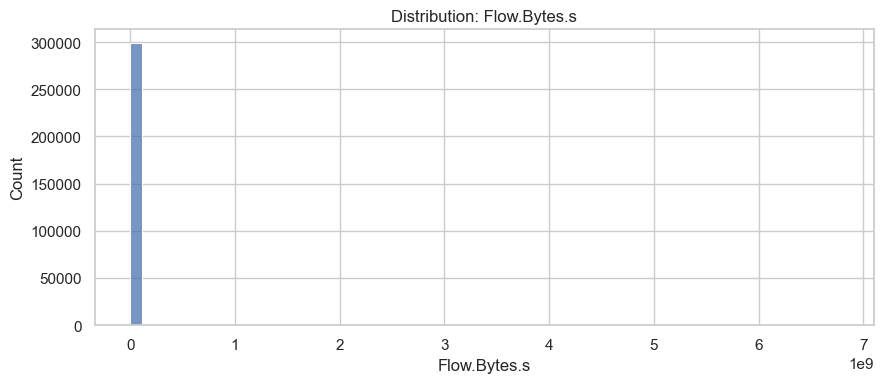

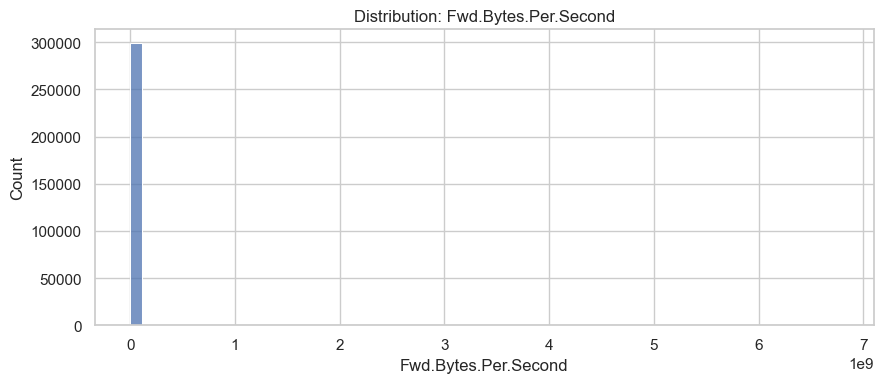

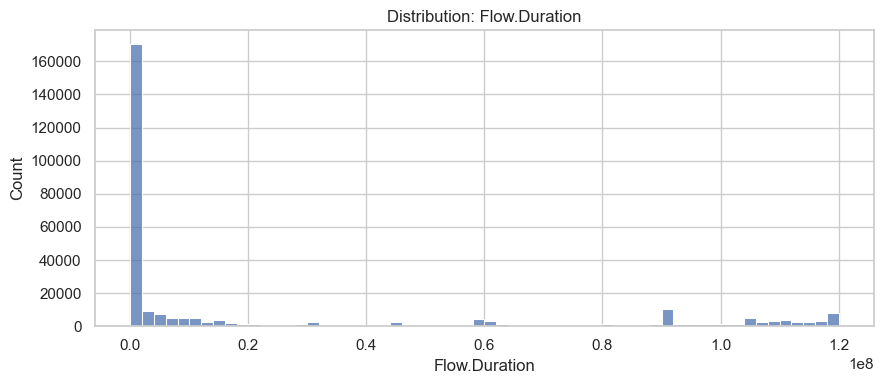

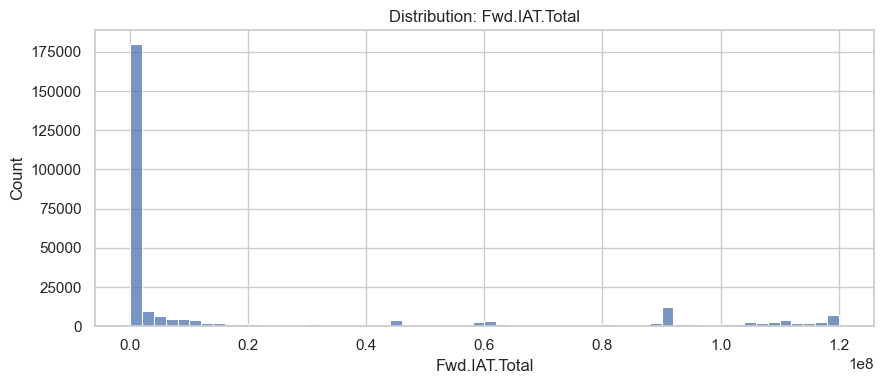

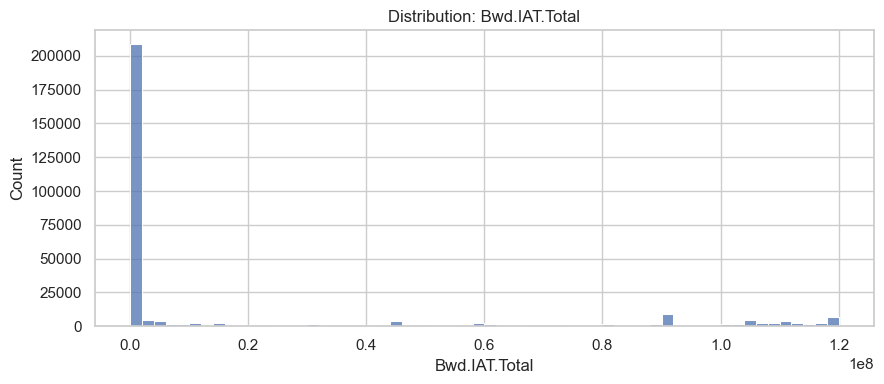

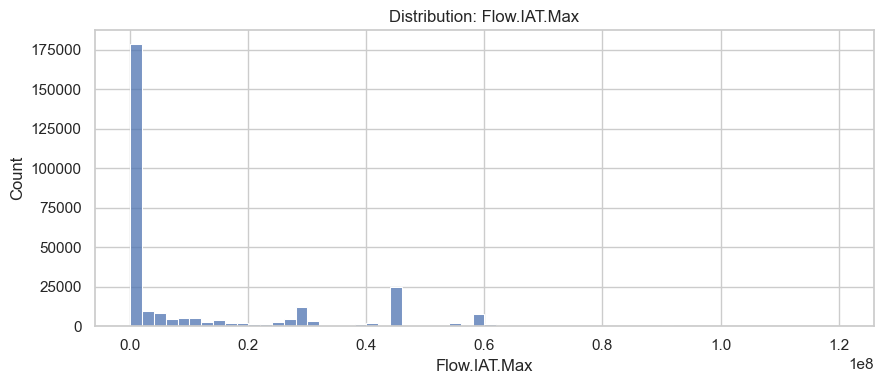

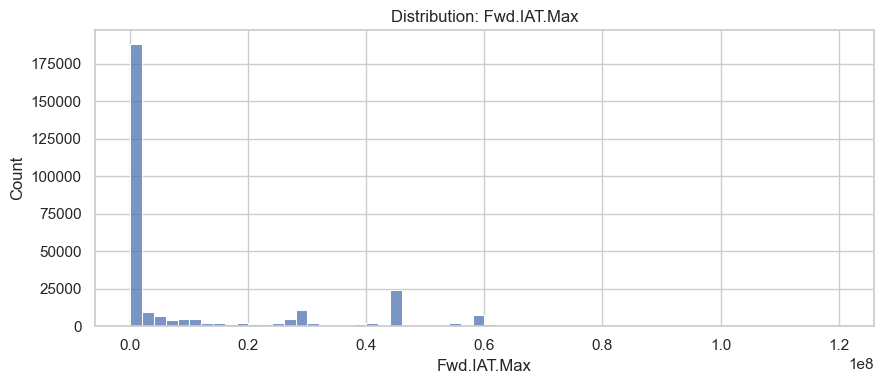

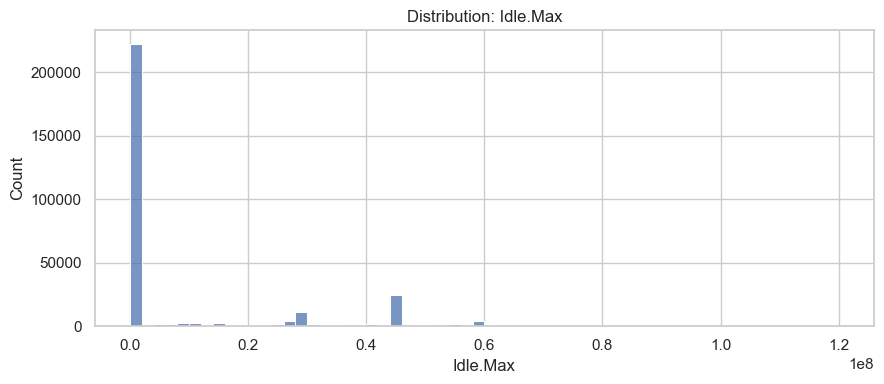

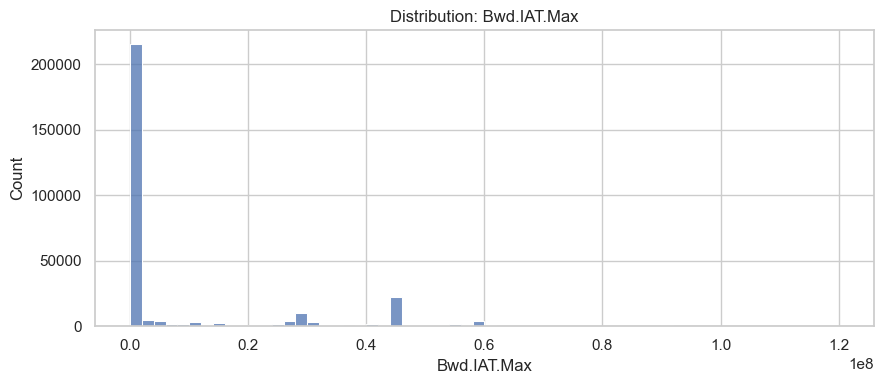

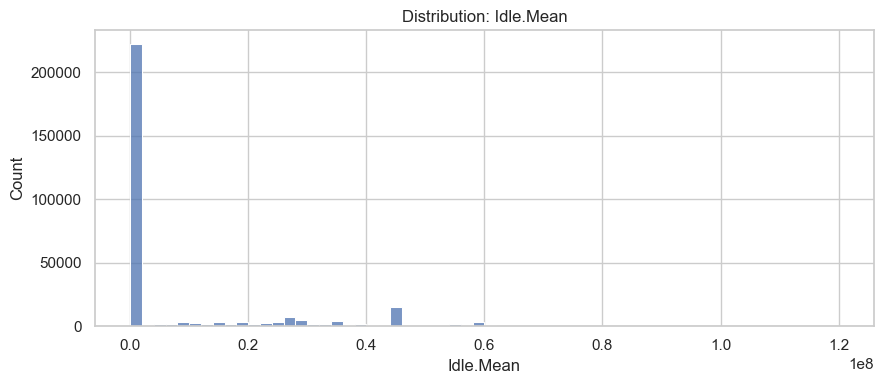

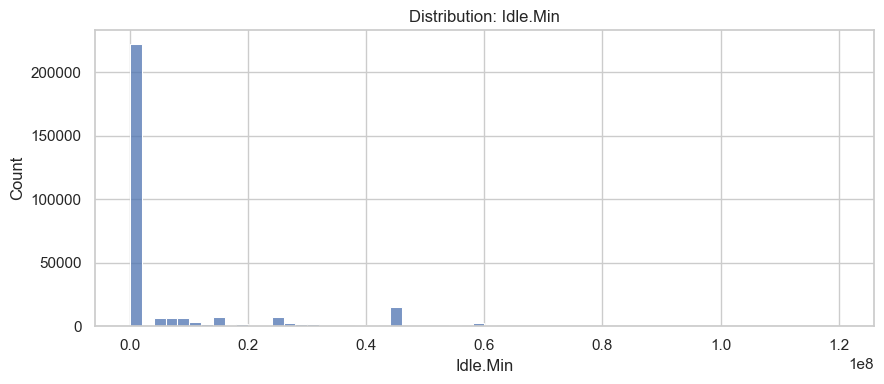

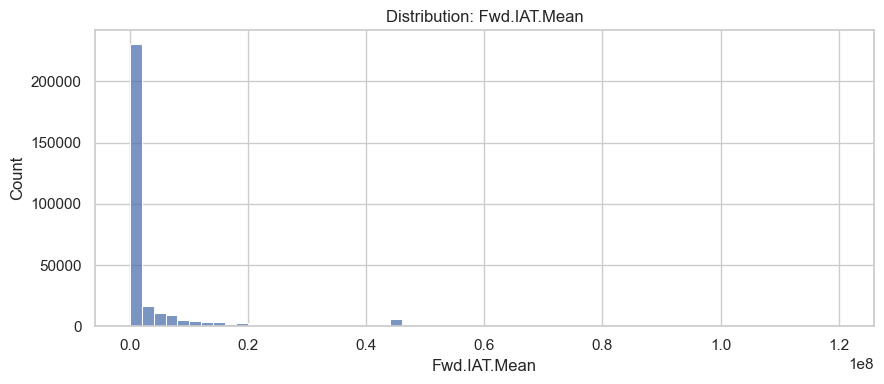

In [12]:

if TARGET is not None:
    numeric_cols = X_engineered.select_dtypes(include=np.number).columns.tolist()

    # Plot up to 12 high-variance numeric features.
    variances = X_engineered[numeric_cols].var(numeric_only=True).sort_values(ascending=False)
    plot_cols = variances.head(12).index.tolist()

    for col in plot_cols:
        plt.figure(figsize=(9, 4))
        sns.histplot(X_engineered[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=60)
        plt.title(f"Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", col)
        plt.savefig(FIG_DIR / f"hist_{safe_name}.png", dpi=160, bbox_inches="tight")
        plt.show()



## 9. Correlation analysis

Correlation helps identify redundant numeric variables. It is not evidence of causation and should not be interpreted as such.


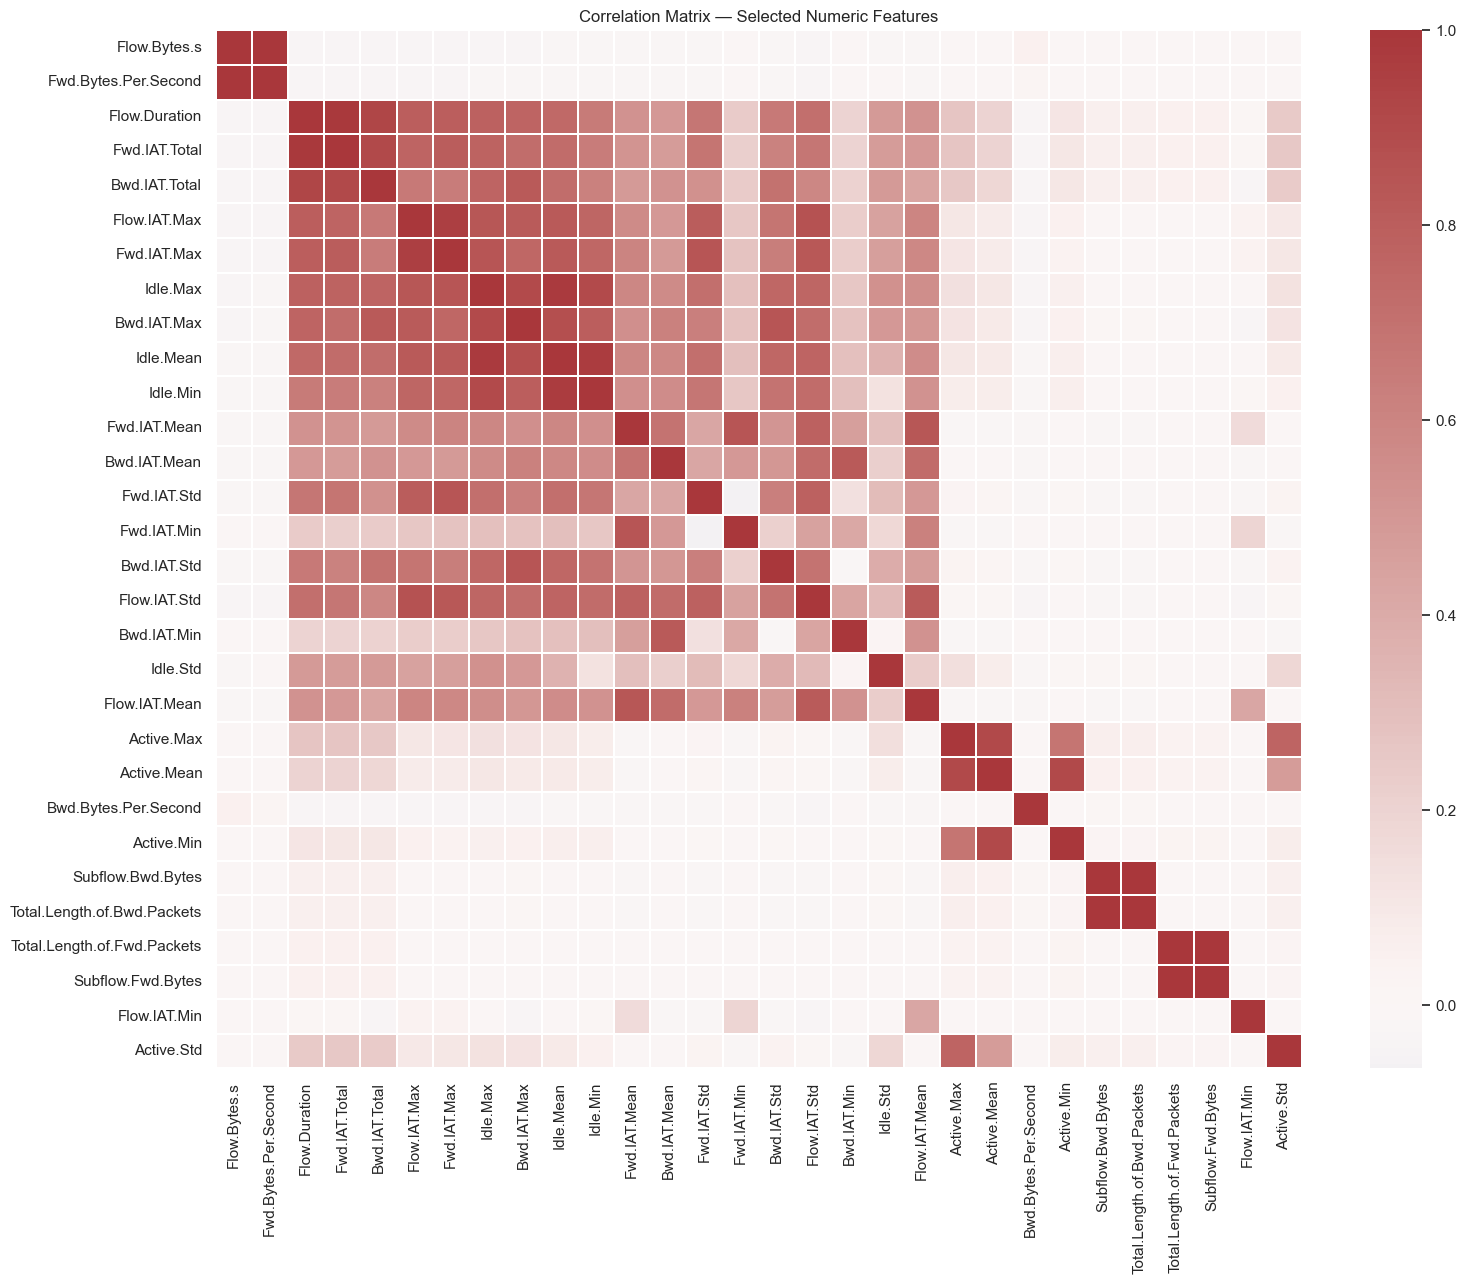

In [13]:

if TARGET is not None:
    corr_cols = X_engineered.select_dtypes(include=np.number).columns.tolist()

    # Limit the heatmap to the 30 most variable numeric features for readability.
    corr_plot_cols = (
        X_engineered[corr_cols]
        .var(numeric_only=True)
        .sort_values(ascending=False)
        .head(30)
        .index
    )

    corr = X_engineered[corr_plot_cols].corr()

    plt.figure(figsize=(16, 13))
    sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.2)
    plt.title("Correlation Matrix — Selected Numeric Features")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "02_correlation_heatmap.png", dpi=180, bbox_inches="tight")
    plt.show()



## 10. Application-specific feature comparisons

For readability, we focus on the most frequent application classes. Boxplots show whether a network-flow feature has visibly different distributions across applications.


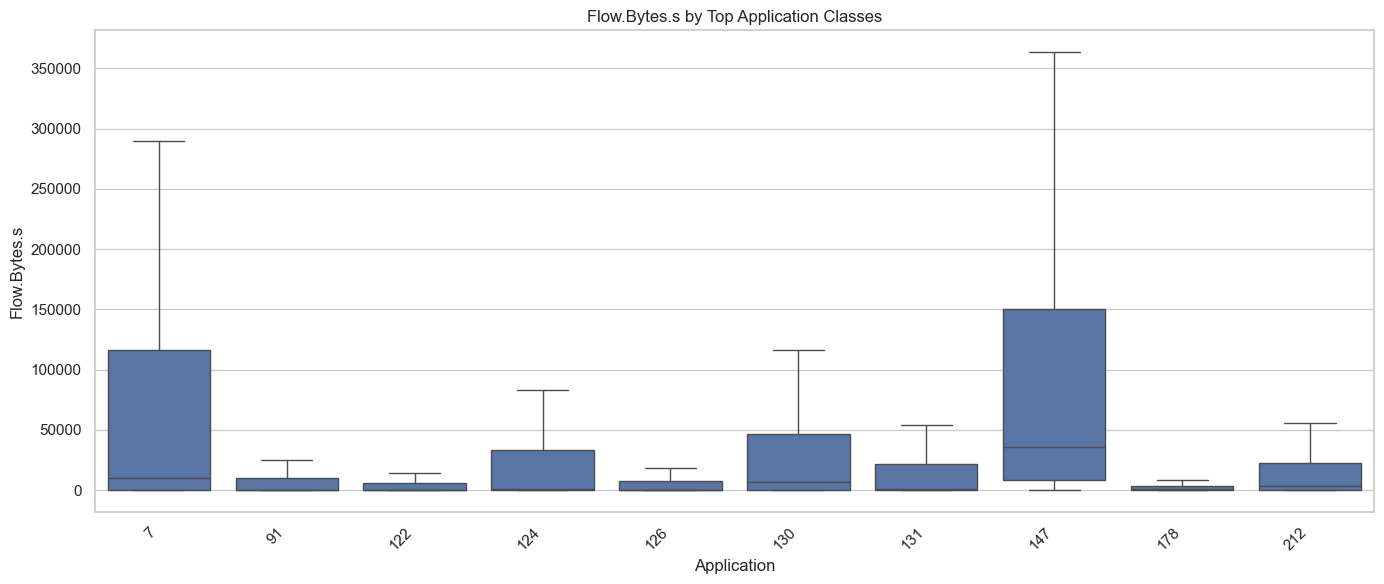

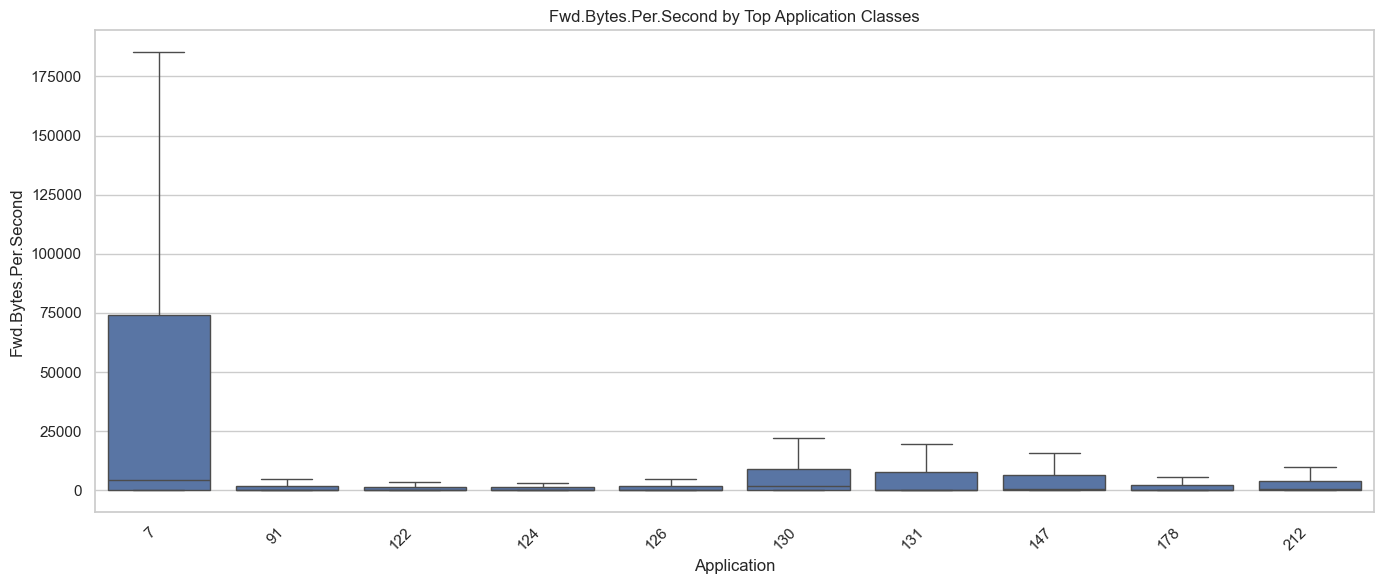

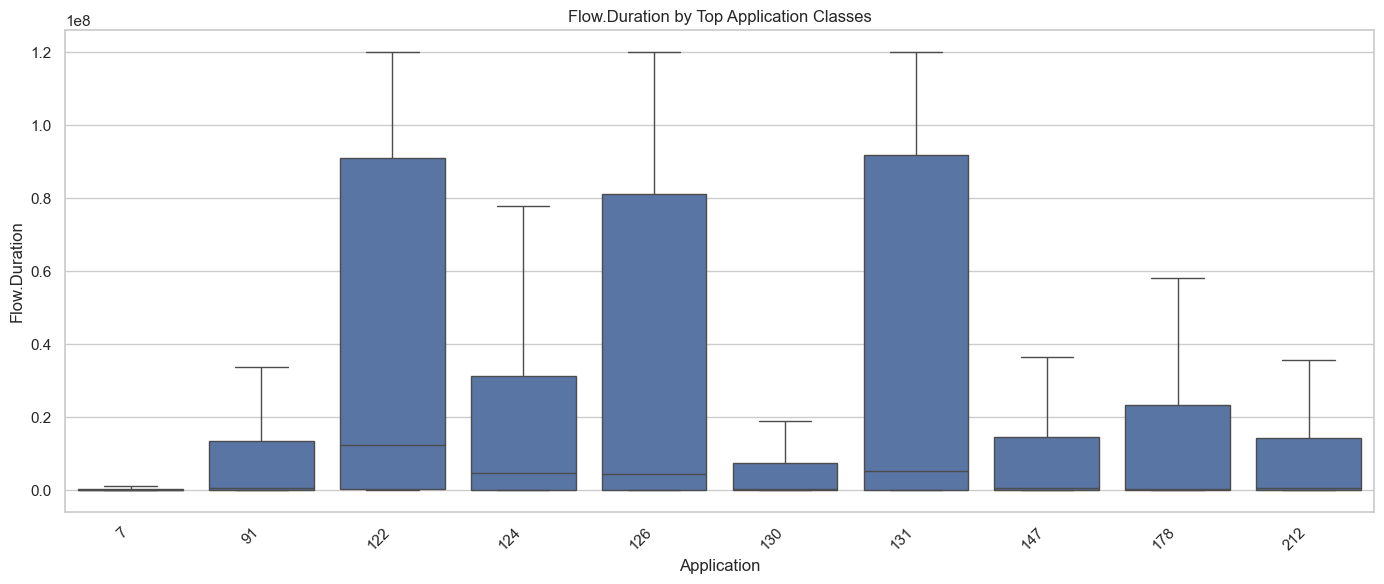

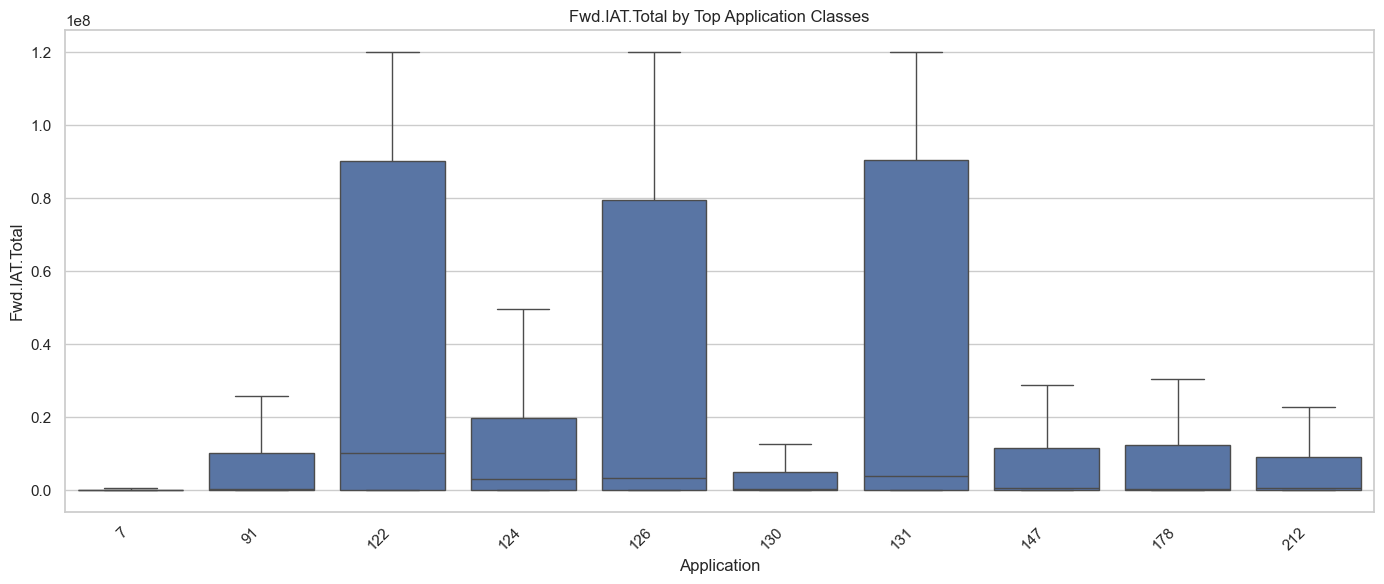

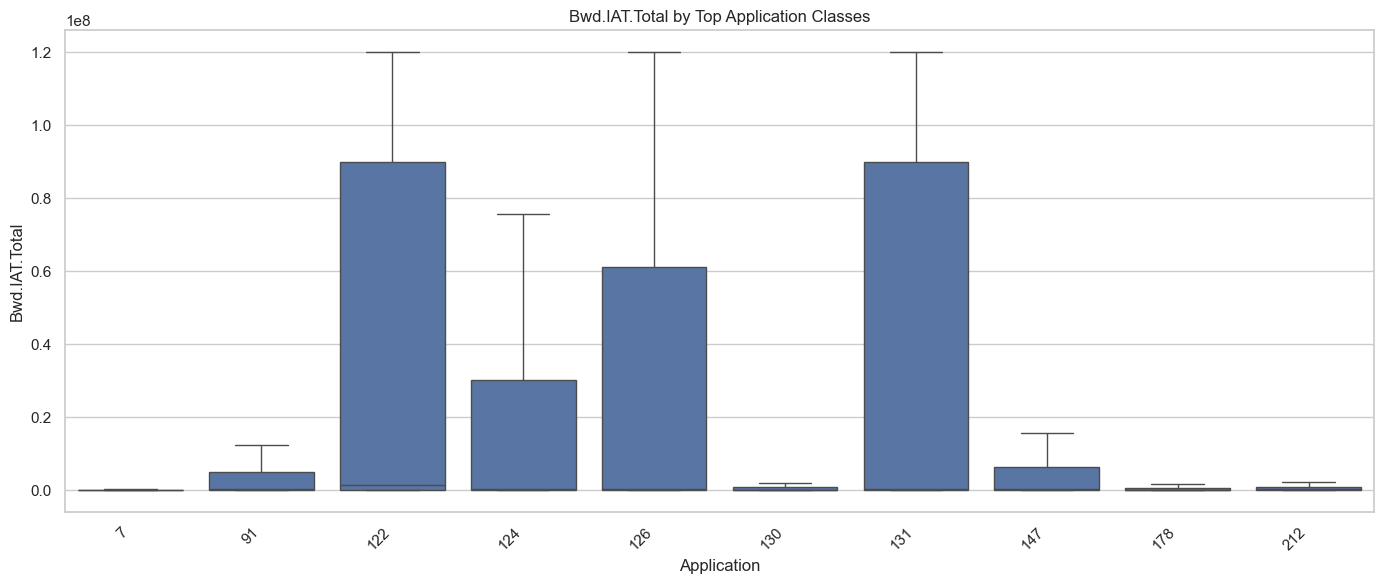

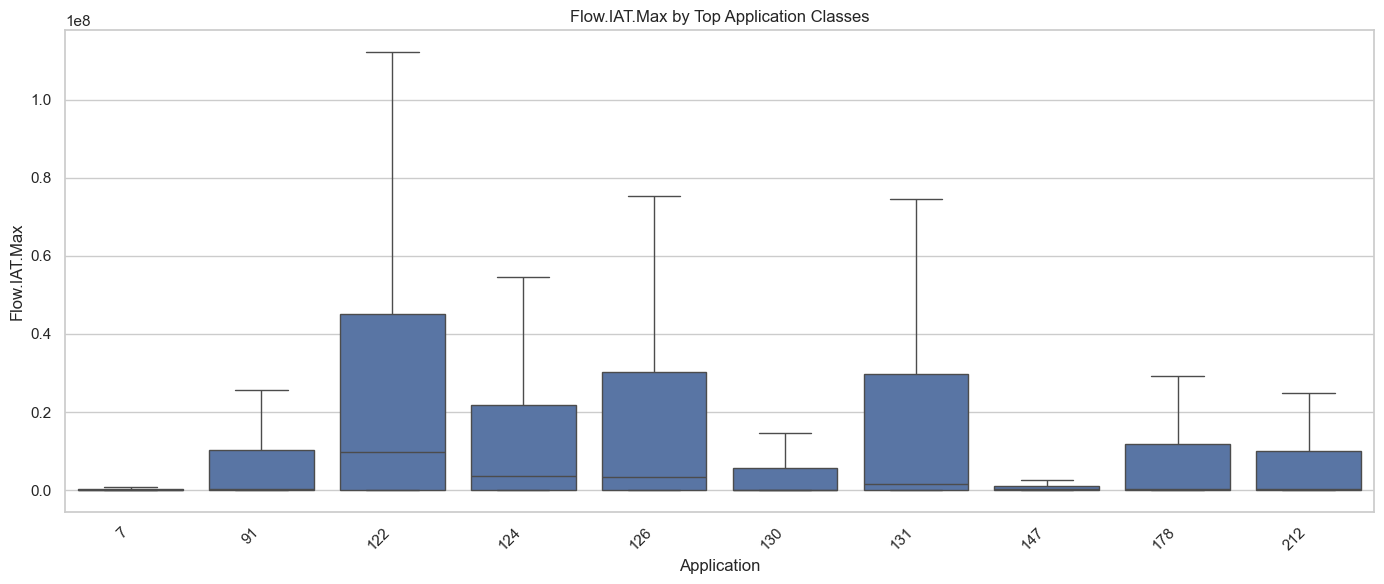

In [14]:

if TARGET is not None:
    top_classes = y.value_counts().head(10).index
    eda_df = X_engineered.copy()
    eda_df["_target_"] = y.values

    numeric_cols = eda_df.select_dtypes(include=np.number).columns.tolist()
    variance_rank = eda_df[numeric_cols].var().sort_values(ascending=False)
    comparison_features = variance_rank.head(6).index.tolist()

    for col in comparison_features:
        temp = eda_df[eda_df["_target_"].isin(top_classes)].copy()

        plt.figure(figsize=(14, 6))
        sns.boxplot(
            data=temp,
            x="_target_",
            y=col,
            showfliers=False
        )
        plt.title(f"{col} by Top Application Classes")
        plt.xlabel("Application")
        plt.ylabel(col)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", col)
        plt.savefig(FIG_DIR / f"boxplot_{safe_name}.png", dpi=160, bbox_inches="tight")
        plt.show()



## 11. PCA visualization

PCA is used for exploratory visualization rather than as proof that the original feature space is linearly separable.

We use a numeric-only preprocessing path and plot the first two principal components for a subset of observations.


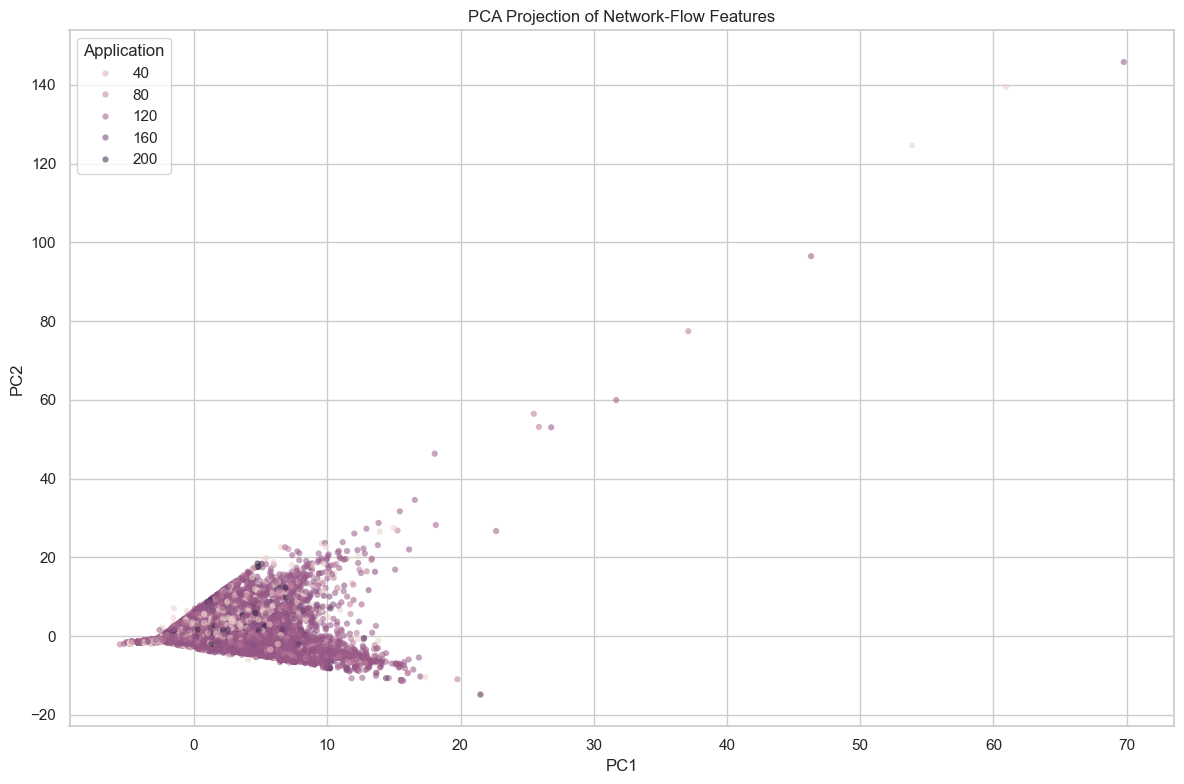

Explained variance: [0.1561238  0.14265544]
Total explained by PC1+PC2: 0.29877924291524743


In [15]:

if TARGET is not None:
    numeric = X_engineered.select_dtypes(include=np.number).copy()
    numeric = numeric.replace([np.inf, -np.inf], np.nan)

    # Avoid extreme memory usage for PCA.
    pca_n = min(50_000, len(numeric))
    pca_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
        len(numeric), size=pca_n, replace=False
    )

    pca_data = numeric.iloc[pca_sample_idx]
    pca_labels = y.iloc[pca_sample_idx]

    pca_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=2, random_state=RANDOM_STATE))
    ])

    coords = pca_pipe.fit_transform(pca_data)

    pca_plot = pd.DataFrame({
        "PC1": coords[:, 0],
        "PC2": coords[:, 1],
        "Application": pca_labels.values
    })

    # Plot only the most frequent classes to preserve readability.
    top = pca_plot["Application"].value_counts().head(15).index
    pca_plot = pca_plot[pca_plot["Application"].isin(top)]

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        data=pca_plot,
        x="PC1",
        y="PC2",
        hue="Application",
        s=20,
        alpha=0.55,
        linewidth=0
    )
    plt.title("PCA Projection of Network-Flow Features")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "03_pca_application_projection.png", dpi=180, bbox_inches="tight")
    plt.show()

    explained = pca_pipe.named_steps["pca"].explained_variance_ratio_
    print("Explained variance:", explained)
    print("Total explained by PC1+PC2:", explained.sum())



## 12. Prepare train/test data

The split happens before fitting preprocessing steps to avoid test-set leakage.

The preprocessing pipeline:

- median imputation for numeric features
- standardization for numeric features
- one-hot encoding for remaining categorical features

For very high-cardinality raw identifiers, use the exclusion list rather than one-hot encoding millions of unique values.


In [16]:

if TARGET is not None:
    X = X_engineered.copy()

    # Drop columns that are completely empty after cleaning.
    X = X.dropna(axis=1, how="all")

    # Remove boolean/object identifiers that should not be modeled.
    # Add more columns to EXCLUDE_COLUMNS above if schema inspection identifies leakage.
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

    # Verify stratification is possible before splitting.
    split_counts = y.value_counts()
    print("Minimum class count before train/test split:", split_counts.min())
    if split_counts.min() < 2:
        raise ValueError(
            "A class has fewer than 2 observations. The modeling sample must "
            "exclude classes with fewer than 20 original observations. "
            "Re-run the notebook from the beginning so Cell 13 rebuilds model_df."
        )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocess = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    print("Train:", X_train.shape)
    print("Test:", X_test.shape)
    print("Numeric features:", len(numeric_features))
    print("Categorical features:", len(categorical_features))


Minimum class count before train/test split: 20
Train: (240000, 88)
Test: (60000, 88)
Numeric features: 88
Categorical features: 0



# 13. Multiclass classification models

The baseline is **Logistic Regression**. We then compare it with:

- Decision Tree
- Random Forest
- Naive Bayes
- KNN

The notebook records accuracy, balanced accuracy, macro F1, weighted F1, precision, and recall.


In [18]:

if TARGET is not None:
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=300,
            solver="saga",
            random_state=RANDOM_STATE,
            n_jobs=1
        ),
        "Decision Tree": DecisionTreeClassifier(
            max_depth=25,
            min_samples_leaf=2,
            random_state=RANDOM_STATE
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=2,
            n_jobs=1,
            random_state=RANDOM_STATE
        )
    }

    results = []
    fitted_models = {}
    predictions = {}

    for name, model in models.items():
        print(f"Training {name}...")
        pipe = Pipeline([
            ("preprocess", preprocess),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        p, r, f, _ = precision_recall_fscore_support(
            y_test, pred, average="macro", zero_division=0
        )
        pw, rw, fw, _ = precision_recall_fscore_support(
            y_test, pred, average="weighted", zero_division=0
        )

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, pred),
            "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
            "Macro Precision": p,
            "Macro Recall": r,
            "Macro F1": f,
            "Weighted Precision": pw,
            "Weighted Recall": rw,
            "Weighted F1": fw
        })

        fitted_models[name] = pipe
        predictions[name] = pred

    results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False)
    display(results_df)
    results_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)


Training Logistic Regression...
Training Decision Tree...
Training Random Forest...


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,Decision Tree,0.685800,0.380303,0.440149,0.380303,0.394950,0.678715,0.685800,0.680298
2,Random Forest,0.742867,0.312883,0.649849,0.312883,0.375104,0.748580,0.742867,0.723559
0,Logistic Regression,0.480967,0.090634,0.130899,0.090634,0.091315,0.467148,0.480967,0.445882



## 14. Model comparison visualization


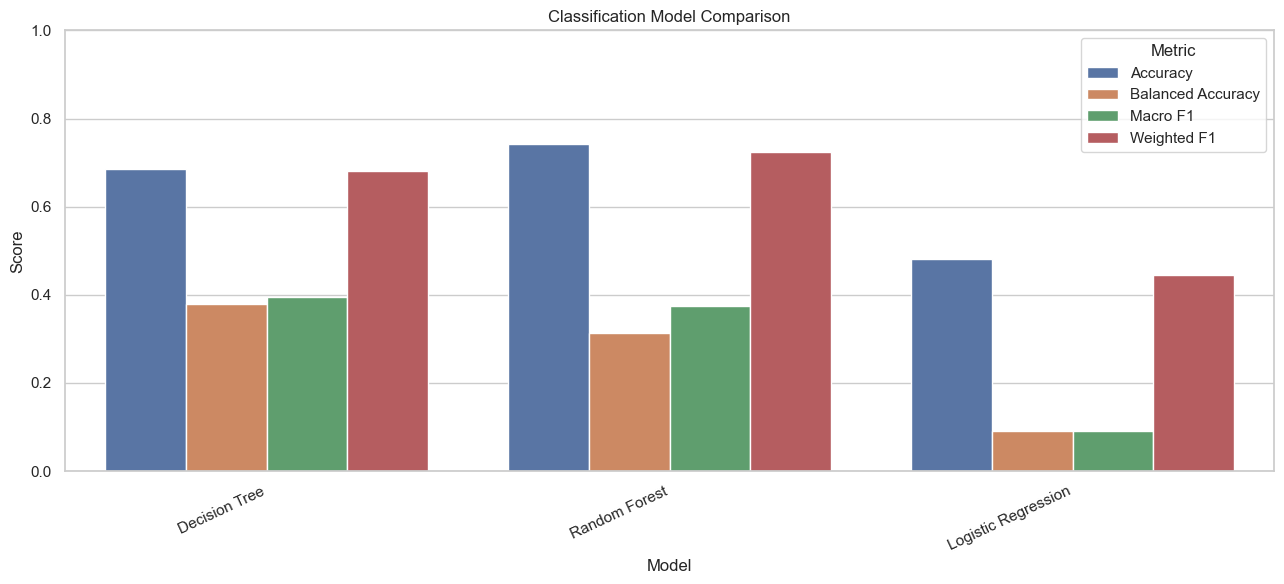

In [19]:

if TARGET is not None:
    plot_metrics = results_df.melt(
        id_vars="Model",
        value_vars=["Accuracy", "Balanced Accuracy", "Macro F1", "Weighted F1"],
        var_name="Metric",
        value_name="Score"
    )

    plt.figure(figsize=(13, 6))
    sns.barplot(data=plot_metrics, x="Model", y="Score", hue="Metric")
    plt.ylim(0, 1)
    plt.title("Classification Model Comparison")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "04_model_comparison.png", dpi=180, bbox_inches="tight")
    plt.show()



## 15. Actual vs predicted labels

This creates the requested row-level comparison dataset.

For each test observation we retain:

- actual application
- each model's prediction
- correctness for each model

This is saved as CSV so it can be inspected in Excel or used for error analysis.


In [29]:

if TARGET is not None:
    comparison = pd.DataFrame({
        "Actual_Label": y_test.reset_index(drop=True)
    })

    for name, pred in predictions.items():
        safe = re.sub(r"[^A-Za-z0-9]+", "_", name).strip("_")
        comparison[f"{safe}_Prediction"] = pred
        comparison[f"{safe}_Correct"] = (
            comparison["Actual_Label"] == comparison[f"{safe}_Prediction"]
        )

    comparison.to_csv(OUTPUT_DIR / "actual_vs_predicted.csv", index=False)

    display(comparison.head(25))
    print("Saved:", OUTPUT_DIR / "actual_vs_predicted.csv")


,Actual_Label,Logistic_Regression_Prediction,Logistic_Regression_Correct,Decision_Tree_Prediction,Decision_Tree_Correct,Random_Forest_Prediction,Random_Forest_Correct
0,130,126,False,130,True,130,True
1,124,126,False,124,True,126,False
2,131,131,True,130,False,130,False
3,130,131,False,130,True,131,False
4,130,126,False,130,True,130,True
5,131,130,False,131,True,7,False
6,131,126,False,131,True,131,True
7,131,126,False,131,True,131,True
8,91,91,True,122,False,126,False
9,130,126,False,130,True,130,True


Saved: /Users/venky.natham/github_projects/berkeley/capstone_project/outputs/actual_vs_predicted.csv



## 16. Confusion matrix

A 75+ class confusion matrix is difficult to read at full resolution. We therefore provide:

1. a full matrix saved to disk;
2. a readable matrix for the most frequent application classes.


Best model based on Macro F1: Decision Tree
Number of classes evaluated: 55
Confusion matrix shape: (55, 55)


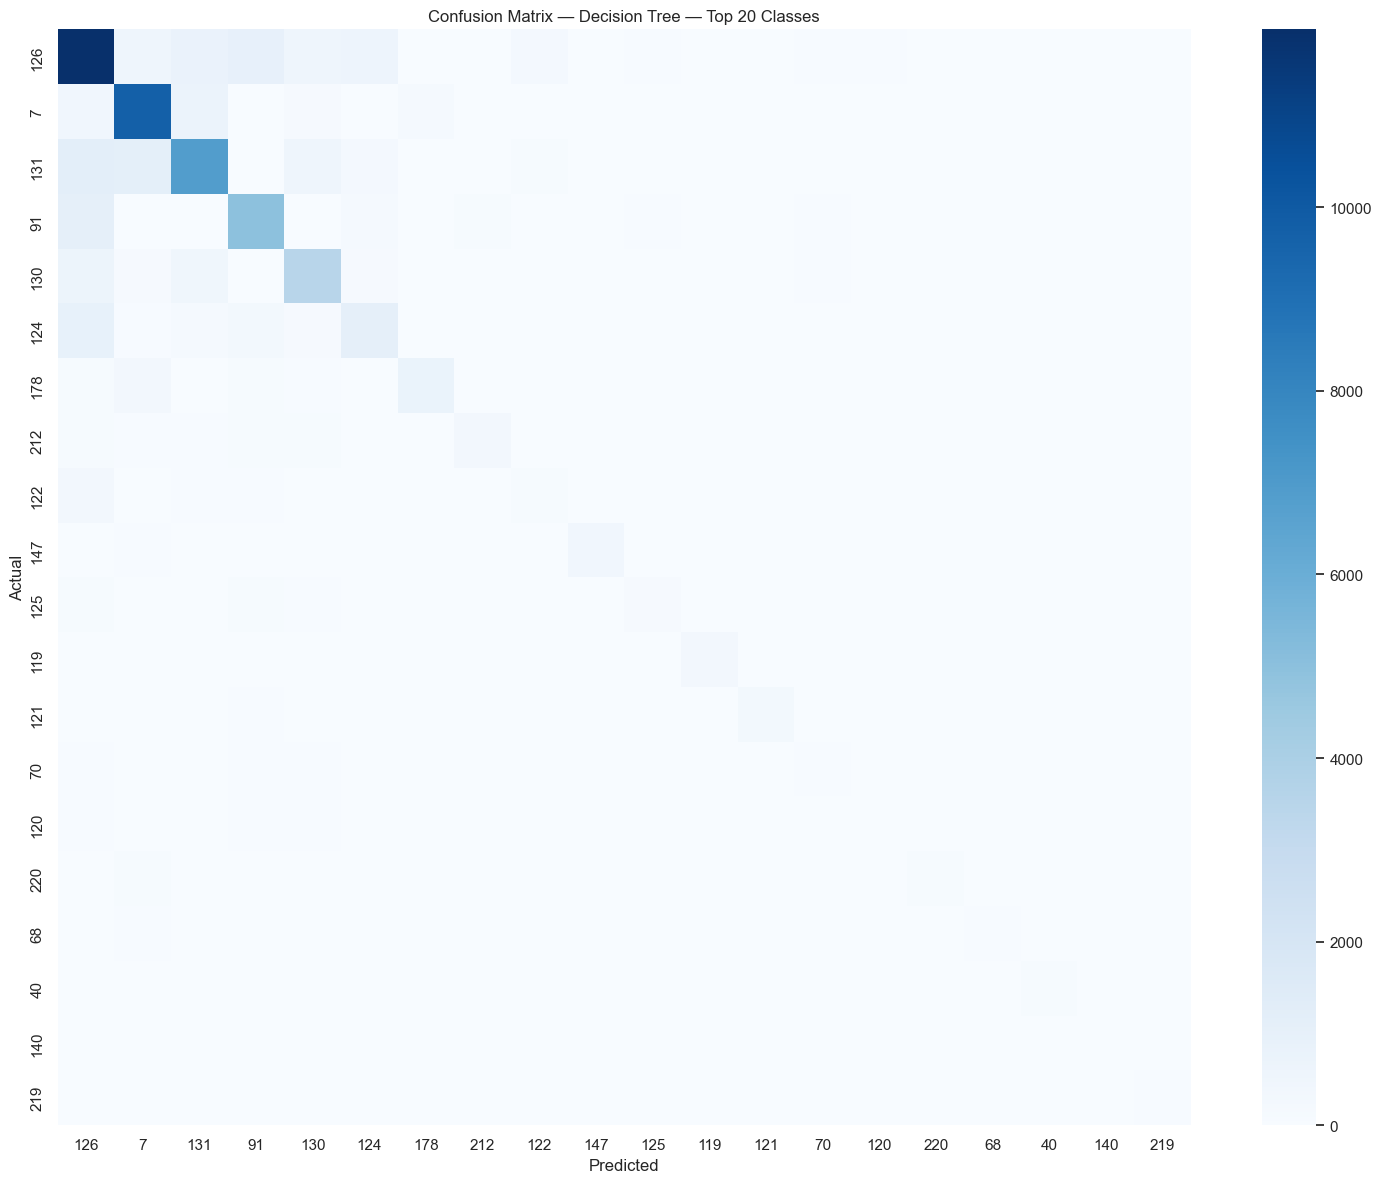

In [30]:

if TARGET is not None:
    best_model_name = results_df.iloc[0]["Model"]
    best_pred = predictions[best_model_name]

    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, best_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    cm_df.to_csv(OUTPUT_DIR / "confusion_matrix_full.csv")

    top_labels = y_test.value_counts().head(20).index.tolist()
    cm_top = confusion_matrix(
        y_test[y_test.isin(top_labels)],
        pd.Series(best_pred, index=y_test.index)[y_test.isin(top_labels)],
        labels=top_labels
    )

    print("Best model based on Macro F1:", best_model_name)
    print("Number of classes evaluated:", len(labels))
    print("Confusion matrix shape:", cm_df.shape)

    plt.figure(figsize=(15, 12))
    sns.heatmap(
        cm_top,
        xticklabels=top_labels,
        yticklabels=top_labels,
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix — {best_model_name} — Top 20 Classes")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "05_confusion_matrix_top20.png", dpi=180, bbox_inches="tight")
    plt.show()



## 17. Per-class performance and error analysis


In [35]:
# 17. Per-class performance and error analysis

if TARGET is not None:

    # Generate complete classification report
    report = classification_report(
        y_test,
        best_pred,
        output_dict=True,
        zero_division=0
    )

    # Convert report to DataFrame
    report_all_df = pd.DataFrame(report).T

    # classification_report stores class labels as strings.
    # Convert the expected labels to strings before filtering.
    class_label_strings = [str(x) for x in labels]

    # Keep only actual application classes.
    # This removes accuracy, macro avg, and weighted avg rows.
    report_df = report_all_df[
        report_all_df.index.astype(str).isin(class_label_strings)
    ].copy()

    # Sort by F1 score so the weakest-performing classes appear first.
    report_df = report_df.sort_values("f1-score")

    # Make sure these are numeric columns
    metric_columns = [
        "precision",
        "recall",
        "f1-score",
        "support"
    ]

    for col in metric_columns:
        report_df[col] = pd.to_numeric(
            report_df[col],
            errors="coerce"
        )

    print("Best model:", best_model_name)

    print("\nOverall performance:")
    print(f"Accuracy:          {report['accuracy']:.4f}")
    print(f"Macro Precision:   {report['macro avg']['precision']:.4f}")
    print(f"Macro Recall:      {report['macro avg']['recall']:.4f}")
    print(f"Macro F1:          {report['macro avg']['f1-score']:.4f}")
    print(f"Weighted Precision:{report['weighted avg']['precision']:.4f}")
    print(f"Weighted Recall:   {report['weighted avg']['recall']:.4f}")
    print(f"Weighted F1:       {report['weighted avg']['f1-score']:.4f}")

    print("\nPER-CLASS PERFORMANCE — ALL CLASSES")
    print("-" * 70)

    display(report_df)

    print(
        f"\nTotal application classes evaluated: {len(report_df)}"
    )

    # Save complete per-class results
    report_df.to_csv(
        OUTPUT_DIR / "per_class_metrics.csv",
        index=True
    )

    print(
        "\nComplete per-class results saved to:"
    )
    print(
        OUTPUT_DIR / "per_class_metrics.csv"
    )

    # ---------------------------------------------------------
    # Most confused actual/predicted pairs
    # ---------------------------------------------------------

    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)

    pairs = []

    for i, actual in enumerate(labels):
        for j, pred in enumerate(labels):

            if cm_no_diag[i, j] > 0:

                pairs.append({
                    "Actual": actual,
                    "Predicted": pred,
                    "Count": int(cm_no_diag[i, j])
                })

    confusion_pairs = (
        pd.DataFrame(pairs)
        .sort_values("Count", ascending=False)
        .head(30)
    )

    display(confusion_pairs)

    confusion_pairs.to_csv(
        OUTPUT_DIR / "top_confusion_pairs.csv",
        index=False
    )

    print(
        "\nTop confusion pairs saved to:"
    )
    print(
        OUTPUT_DIR / "top_confusion_pairs.csv"
    )

Best model: Decision Tree

Overall performance:
Accuracy:          0.6858
Macro Precision:   0.4401
Macro Recall:      0.3803
Macro F1:          0.3949
Weighted Precision:0.6787
Weighted Recall:   0.6858
Weighted F1:       0.6803

PER-CLASS PERFORMANCE — ALL CLASSES
----------------------------------------------------------------------


,precision,recall,f1-score,support
180,0.000000,0.000000,0.000000,4.0
163,0.000000,0.000000,0.000000,8.0
158,0.000000,0.000000,0.000000,4.0
156,0.000000,0.000000,0.000000,25.0
153,0.000000,0.000000,0.000000,4.0
175,0.000000,0.000000,0.000000,8.0
123,0.000000,0.000000,0.000000,17.0
191,0.000000,0.000000,0.000000,4.0
195,0.000000,0.000000,0.000000,4.0
179,0.000000,0.000000,0.000000,24.0



Total application classes evaluated: 55

Complete per-class results saved to:
/Users/venky.natham/github_projects/berkeley/capstone_project/outputs/per_class_metrics.csv


,Actual,Predicted,Count
270,131,126,1168
255,131,7,1134
83,91,126,1078
208,126,91,1010
179,124,126,967
218,126,131,823
19,7,131,714
243,130,126,692
215,126,124,623
271,131,130,579



Top confusion pairs saved to:
/Users/venky.natham/github_projects/berkeley/capstone_project/outputs/top_confusion_pairs.csv



# 18. Unsupervised clustering

K-Means is included as an exploratory unsupervised method.

Cluster IDs are **not** assumed to equal application labels. Instead we compare cluster assignments to the known application labels using:

- Adjusted Rand Index
- Normalized Mutual Information
- Silhouette score

Because the dataset has many classes, K is set to the number of observed classes in the modeling sample.


In [36]:

if TARGET is not None:
    numeric = X_engineered.select_dtypes(include=np.number).replace(
        [np.inf, -np.inf], np.nan
    )

    # Use a smaller clustering sample.
    cluster_n = min(75_000, len(numeric))
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(numeric), size=cluster_n, replace=False)

    cluster_X = numeric.iloc[idx]
    cluster_y = y.iloc[idx].values

    scaler = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    Z = scaler.fit_transform(cluster_X)

    n_clusters = y.nunique()
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=RANDOM_STATE,
        batch_size=2048,
        n_init=5
    )

    cluster_labels = kmeans.fit_predict(Z)

    ari = adjusted_rand_score(cluster_y, cluster_labels)
    nmi = normalized_mutual_info_score(cluster_y, cluster_labels)

    # Silhouette can be expensive; use at most 10k observations.
    sil_n = min(10_000, len(Z))
    sil_idx = rng.choice(len(Z), size=sil_n, replace=False)
    sil = silhouette_score(Z[sil_idx], cluster_labels[sil_idx])

    clustering_results = pd.DataFrame([{
        "Method": "MiniBatchKMeans",
        "Clusters": n_clusters,
        "Adjusted Rand Index": ari,
        "Normalized Mutual Information": nmi,
        "Silhouette Score": sil
    }])

    print("\nK-Means results")
    print("----------------")
    print(f"Number of clusters:       {n_clusters}")
    print(f"Adjusted Rand Index:      {ari:.4f}")
    print(f"Normalized Mutual Info:   {nmi:.4f}")
    print(f"Silhouette Score:          {sil:.4f}")

    display(clustering_results)

    display(clustering_results)
    clustering_results.to_csv(OUTPUT_DIR / "clustering_results.csv", index=False)



K-Means results
----------------
Number of clusters:       55
Adjusted Rand Index:      0.0399
Normalized Mutual Info:   0.1455
Silhouette Score:          0.2430


,Method,Clusters,Adjusted Rand Index,Normalized Mutual Information,Silhouette Score
0,MiniBatchKMeans,55,0.039944,0.145548,0.24304


,Method,Clusters,Adjusted Rand Index,Normalized Mutual Information,Silhouette Score
0,MiniBatchKMeans,55,0.039944,0.145548,0.24304



## 19. Clustering visualization with PCA


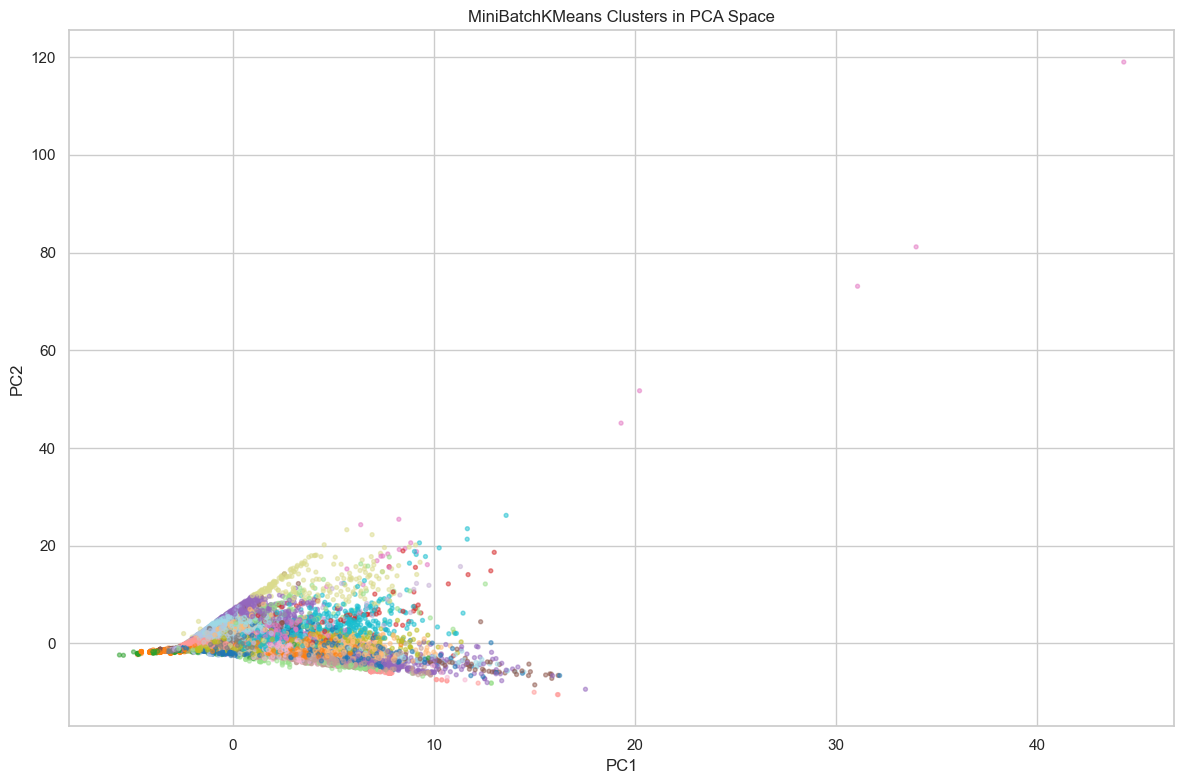

In [37]:

if TARGET is not None:
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Z)

    plot_n = min(20_000, len(coords))
    idx2 = rng.choice(len(coords), size=plot_n, replace=False)

    plt.figure(figsize=(12, 8))
    plt.scatter(
        coords[idx2, 0],
        coords[idx2, 1],
        c=cluster_labels[idx2],
        s=8,
        alpha=0.5,
        cmap="tab20"
    )
    plt.title("MiniBatchKMeans Clusters in PCA Space")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "06_kmeans_pca.png", dpi=180, bbox_inches="tight")
    plt.show()



# 20. Feature importance / discriminatory information

For the baseline, Logistic Regression coefficients can be useful for interpretation when the transformed feature space is manageable.

For Random Forest, feature importance provides a second interpretation of which predictors contribute most to classification.

Because one-hot encoding and preprocessing can expand the feature space, we extract transformed feature names before ranking.


,Feature,Importance
1,num__Destination.Port,0.094308
0,num__Source.Port,0.057271
69,num__Init_Win_bytes_backward,0.041660
68,num__Init_Win_bytes_forward,0.039002
8,num__Fwd.Packet.Length.Max,0.020683
20,num__Flow.IAT.Max,0.019912
71,num__min_seg_size_forward,0.019872
3,num__Flow.Duration,0.019570
18,num__Flow.IAT.Mean,0.016638
25,num__Fwd.IAT.Max,0.015922


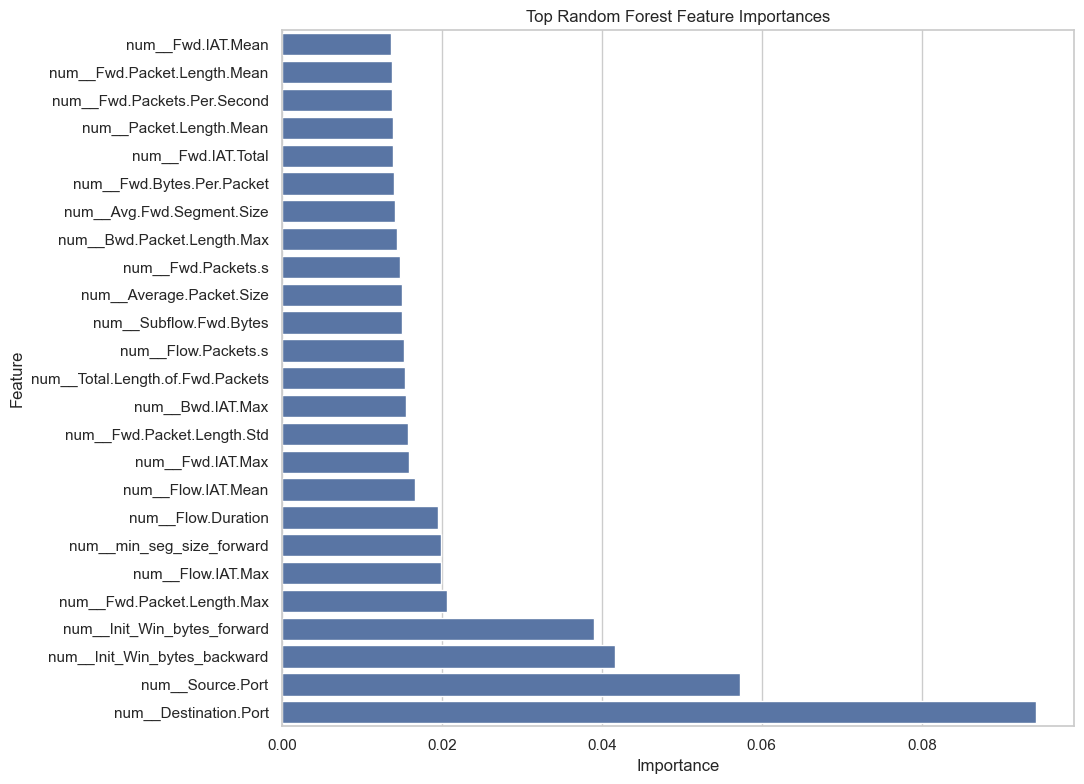

In [38]:

if TARGET is not None and "Random Forest" in fitted_models:
    rf_pipe = fitted_models["Random Forest"]

    try:
        feature_names = rf_pipe.named_steps["preprocess"].get_feature_names_out()
        importances = rf_pipe.named_steps["model"].feature_importances_

        fi = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        }).sort_values("Importance", ascending=False).head(25)

        display(fi)

        plt.figure(figsize=(11, 8))
        sns.barplot(data=fi.sort_values("Importance"), x="Importance", y="Feature")
        plt.title("Top Random Forest Feature Importances")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "07_random_forest_feature_importance.png", dpi=180, bbox_inches="tight")
        plt.show()

        fi.to_csv(OUTPUT_DIR / "random_forest_feature_importance.csv", index=False)
    except Exception as e:
        print("Feature importance extraction skipped:", e)



# 21. Mutual information ranking

Mutual information is an additional exploratory feature-ranking technique. It can capture nonlinear relationships that ordinary correlation may miss.

This calculation is performed on a numeric sample for computational efficiency.


,Feature,MutualInformation
1,Destination.Port,0.611137
69,Init_Win_bytes_backward,0.560572
68,Init_Win_bytes_forward,0.453415
12,Bwd.Packet.Length.Max,0.379847
0,Source.Port,0.376147
8,Fwd.Packet.Length.Max,0.372920
41,Max.Packet.Length,0.361900
57,Fwd.Header.Length.1,0.336498
36,Fwd.Header.Length,0.334919
65,Subflow.Fwd.Bytes,0.315172


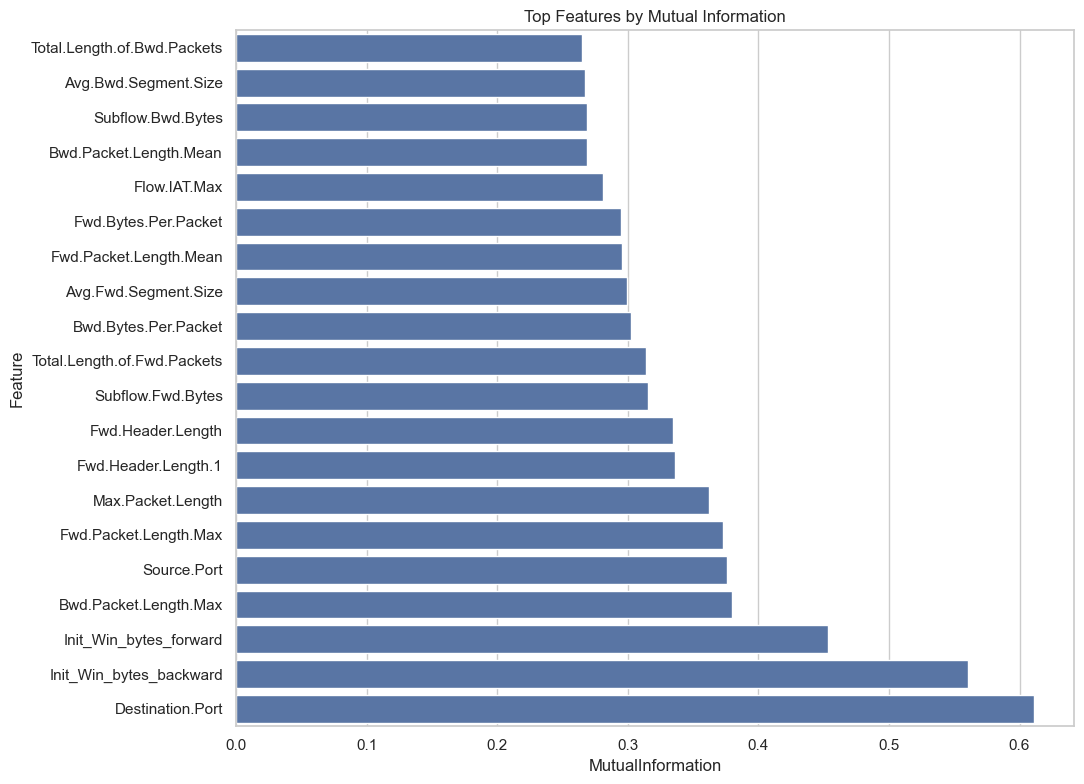

In [39]:

if TARGET is not None:
    mi_df = X_engineered.select_dtypes(include=np.number).replace(
        [np.inf, -np.inf], np.nan
    )

    mi_n = min(50_000, len(mi_df))
    idx = np.random.RandomState(RANDOM_STATE).choice(len(mi_df), size=mi_n, replace=False)

    X_mi = SimpleImputer(strategy="median").fit_transform(mi_df.iloc[idx])
    y_mi = y.iloc[idx]

    le = LabelEncoder()
    y_encoded = le.fit_transform(y_mi)

    mi = mutual_info_classif(
        X_mi,
        y_encoded,
        random_state=RANDOM_STATE
    )

    mi_results = pd.DataFrame({
        "Feature": mi_df.columns,
        "MutualInformation": mi
    }).sort_values("MutualInformation", ascending=False)

    display(mi_results.head(25))

    plt.figure(figsize=(11, 8))
    sns.barplot(
        data=mi_results.head(20).sort_values("MutualInformation"),
        x="MutualInformation",
        y="Feature"
    )
    plt.title("Top Features by Mutual Information")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "08_mutual_information.png", dpi=180, bbox_inches="tight")
    plt.show()

    mi_results.to_csv(OUTPUT_DIR / "mutual_information.csv", index=False)



# 22. Save the cleaned modeling sample

The full raw CSV remains untouched. The following files are derived artifacts.


In [40]:

if TARGET is not None:
    model_df.to_csv(OUTPUT_DIR / "modeling_sample_with_label.csv", index=False)
    X_engineered.to_csv(OUTPUT_DIR / "modeling_features_without_label.csv", index=False)

    print("Saved:")
    print(OUTPUT_DIR / "modeling_sample_with_label.csv")
    print(OUTPUT_DIR / "modeling_features_without_label.csv")


Saved:
/Users/venky.natham/github_projects/berkeley/capstone_project/outputs/modeling_sample_with_label.csv
/Users/venky.natham/github_projects/berkeley/capstone_project/outputs/modeling_features_without_label.csv


# 22. Final Results Summary

In [41]:
# 22. Final Results Summary

print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

if TARGET is not None:

    # ---------------------------------------------------------
    # Dataset / modeling information
    # ---------------------------------------------------------
    print("\nDATASET / MODELING")
    print("-" * 70)

    print("Target variable:", TARGET)

    # Use the full-data profiling result instead of len(sample)
    if "profile" in globals() and "total_rows" in profile:
        print("Original observations:", profile["total_rows"])
    else:
        print("Original observations: 3,577,296")

    print("Modeling sample size:", len(model_df))
    print("Number of modeling classes:", y.nunique())
    print("Minimum class count:", y.value_counts().min())
    print("Training observations:", len(X_train))
    print("Testing observations:", len(X_test))

    # ---------------------------------------------------------
    # Classification results
    # ---------------------------------------------------------
    print("\nCLASSIFICATION RESULTS")
    print("-" * 70)

    classification_columns = [
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1"
    ]

    display(results_df[classification_columns])

    best_model_name = results_df.iloc[0]["Model"]

    print("\nBest model based on Macro F1:")
    print(best_model_name)

    print(
        f"Best Macro F1: "
        f"{results_df.iloc[0]['Macro F1']:.4f}"
    )

    print(
        f"Best Accuracy: "
        f"{results_df.iloc[0]['Accuracy']:.4f}"
    )

    # ---------------------------------------------------------
    # Clustering results
    # ---------------------------------------------------------
    if "clustering_results" in globals():

        print("\nCLUSTERING RESULTS")
        print("-" * 70)

        display(clustering_results)

        print(
            f"Adjusted Rand Index: "
            f"{clustering_results.iloc[0]['Adjusted Rand Index']:.4f}"
        )

        print(
            f"Normalized Mutual Information: "
            f"{clustering_results.iloc[0]['Normalized Mutual Information']:.4f}"
        )

        print(
            f"Silhouette Score: "
            f"{clustering_results.iloc[0]['Silhouette Score']:.4f}"
        )

    # ---------------------------------------------------------
    # COMPLETE per-class performance
    # ---------------------------------------------------------
    if "report_df" in globals():

        print("\nPER-CLASS PERFORMANCE — ALL CLASSES")
        print("-" * 70)

        per_class_display = report_df[
            ["precision", "recall", "f1-score", "support"]
        ].copy()

        # Make class label explicit as a column
        per_class_display.index.name = "L7Protocol"

        display(per_class_display)

        print(
            f"\nTotal application classes displayed: "
            f"{len(per_class_display)}"
        )

        print(
            "\nFull per-class results saved to:"
        )
        print(OUTPUT_DIR / "per_class_metrics.csv")

    # ---------------------------------------------------------
    # Most confused classes
    # ---------------------------------------------------------
    if "confusion_pairs" in globals():

        print("\nTOP CONFUSION PAIRS")
        print("-" * 70)

        display(confusion_pairs)

        print(
            "\nFull confusion-pair results saved to:"
        )
        print(OUTPUT_DIR / "top_confusion_pairs.csv")

    print("\n" + "=" * 70)
    print("All major results have been generated and saved.")
    print("=" * 70)
    

FINAL RESULTS SUMMARY

DATASET / MODELING
----------------------------------------------------------------------
Target variable: L7Protocol
Original observations: 3,577,296
Modeling sample size: 300000
Number of modeling classes: 55
Minimum class count: 20
Training observations: 240000
Testing observations: 60000

CLASSIFICATION RESULTS
----------------------------------------------------------------------


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,Decision Tree,0.685800,0.380303,0.440149,0.380303,0.394950,0.678715,0.685800,0.680298
2,Random Forest,0.742867,0.312883,0.649849,0.312883,0.375104,0.748580,0.742867,0.723559
0,Logistic Regression,0.480967,0.090634,0.130899,0.090634,0.091315,0.467148,0.480967,0.445882



Best model based on Macro F1:
Decision Tree
Best Macro F1: 0.3949
Best Accuracy: 0.6858

CLUSTERING RESULTS
----------------------------------------------------------------------


,Method,Clusters,Adjusted Rand Index,Normalized Mutual Information,Silhouette Score
0,MiniBatchKMeans,55,0.039944,0.145548,0.24304


Adjusted Rand Index: 0.0399
Normalized Mutual Information: 0.1455
Silhouette Score: 0.2430

PER-CLASS PERFORMANCE — ALL CLASSES
----------------------------------------------------------------------


,precision,recall,f1-score,support
L7Protocol,,,,
180,0.000000,0.000000,0.000000,4.0
163,0.000000,0.000000,0.000000,8.0
158,0.000000,0.000000,0.000000,4.0
156,0.000000,0.000000,0.000000,25.0
153,0.000000,0.000000,0.000000,4.0
175,0.000000,0.000000,0.000000,8.0
123,0.000000,0.000000,0.000000,17.0
191,0.000000,0.000000,0.000000,4.0
195,0.000000,0.000000,0.000000,4.0



Total application classes displayed: 55

Full per-class results saved to:
/Users/venky.natham/github_projects/berkeley/capstone_project/outputs/per_class_metrics.csv

TOP CONFUSION PAIRS
----------------------------------------------------------------------


,Actual,Predicted,Count
270,131,126,1168
255,131,7,1134
83,91,126,1078
208,126,91,1010
179,124,126,967
218,126,131,823
19,7,131,714
243,130,126,692
215,126,124,623
271,131,130,579



Full confusion-pair results saved to:
/Users/venky.natham/github_projects/berkeley/capstone_project/outputs/top_confusion_pairs.csv

All major results have been generated and saved.


# 23. Reproducibility Summary

## Data and modeling design

This analysis uses `Dataset-Unicauca-Version2-87Atts.csv`.

- **Original observations:** 3,577,296
- **Original attributes:** 87
- **Original application classes:** 78
- **Target:** `L7Protocol`
- **Modeling sample:** 300,000 observations
- **Classes retained for modeling:** 55
- **Rare classes excluded:** 23
- **Minimum retained class size:** 20
- **Random state:** 42
- **Train/test split:** 80/20 stratified

The complete dataset is processed in chunks for profiling, while computationally intensive modeling uses the reproducible 300,000-row sample.

## Cleaning and leakage prevention

`Flow.ID`, `Source.IP`, `Destination.IP`, `Timestamp`, `Label`, `ProtocolName`, and `L7Protocol` are excluded from predictors to reduce identifier and label leakage. Numeric missing values are median-imputed and standardized. The analysis also engineers flow rates and forward/backward ratios; infinite values are converted to missing values before preprocessing.

## Baseline model

This is a **multiclass classification** problem because `L7Protocol` represents the application/protocol class.

**Logistic Regression is the baseline model.** It is appropriate because it provides a standard, comparatively simple reference point against which more flexible nonlinear classifiers can be evaluated.

The baseline is compared with a Decision Tree and Random Forest using the same preprocessing and stratified train/test framework.

## Primary evaluation metric: Macro F1

The **primary evaluation metric is Macro F1**.

F1 combines precision and recall. Macro F1 calculates F1 independently for each application class and then averages those scores with **equal weight for every class**.

### Rationale

The dataset is highly imbalanced. Accuracy alone can be misleading because strong predictions for the largest application classes can hide weak performance on smaller classes. Macro F1 is therefore appropriate because each retained application class contributes equally to model selection.

Accuracy, balanced accuracy, precision, recall, and weighted F1 are also reported as complementary metrics.

### Interpretation

The Decision Tree's Macro F1 of **0.3950** means that the average class-level balance between precision and recall is approximately 0.395 when each of the 55 modeled classes is weighted equally.

This **does not mean 39.5% accuracy**. The Decision Tree's actual accuracy is approximately **68.58%**.

## Actual classification results

| Model | Accuracy | Balanced Accuracy | Macro Precision | Macro Recall | Macro F1 | Weighted F1 |
|---|---:|---:|---:|---:|---:|---:|
| **Decision Tree** | 0.6858 | **0.3803** | 0.4401 | **0.3803** | **0.3950** | 0.6803 |
| **Random Forest** | **0.7429** | 0.3129 | **0.6498** | 0.3129 | 0.3751 | **0.7236** |
| **Logistic Regression (Baseline)** | 0.4810 | 0.0906 | 0.1309 | 0.0906 | 0.0913 | 0.4459 |

Using the stated primary metric, **Decision Tree is selected because it has the highest Macro F1 (0.3950)**.

Random Forest has the highest accuracy (**0.7429**) and weighted F1 (**0.7236**). This is not contradictory: weighted metrics give greater influence to common classes, while Macro F1 gives every class equal influence.

The Logistic Regression baseline has Macro F1 **0.0913**. Both tree-based models substantially improve on this baseline, suggesting that nonlinear relationships in the flow features are important.

## Actual-versus-predicted and per-class analysis

The notebook saves observation-level actual-versus-predicted results to `actual_vs_predicted.csv`. It also produces a confusion matrix, per-class precision/recall/F1/support, and the most common incorrect actual/predicted pairs.

Outputs include:

- `model_comparison.csv`
- `actual_vs_predicted.csv`
- `per_class_metrics.csv`
- `top_confusion_pairs.csv`

These results are especially important because the gap between macro and weighted metrics demonstrates that aggregate accuracy does not fully describe performance across the 55 modeled classes.

## Unsupervised clustering

MiniBatchKMeans is used as an exploratory comparison with 55 clusters.

- **Adjusted Rand Index:** 0.0399
- **Normalized Mutual Information:** 0.1455
- **Silhouette Score:** 0.2430

The low ARI and NMI indicate that the unsupervised clusters do not closely reproduce the application labels. The supervised models are therefore more useful for the stated prediction task.

## Reproducibility controls

`RANDOM_STATE = 42` is used for reproducible sampling, splitting, and applicable model operations. The notebook saves reusable tables and figures so the results can be inspected independently of notebook display output.

## Limitations

1. Modeling uses 300,000 observations rather than all 3,577,296.
2. Twenty-three rare classes are excluded; supervised results apply to 55 retained classes.
3. Strong class imbalance remains.
4. Random stratified splitting may place flows from similar capture conditions in both training and testing data.
5. Identifier and label-equivalent fields are excluded to reduce leakage.
6. K-Means shows weak agreement with known application classes and is treated as exploratory.

## Overall conclusion

The project establishes a reproducible multiclass baseline for application identification from network-flow characteristics. Logistic Regression satisfies the baseline-model requirement, while Decision Tree and Random Forest provide stronger nonlinear comparisons.

**Macro F1 is the primary evaluation metric because the application classes are highly imbalanced and each class should contribute equally to model selection.** By this criterion, Decision Tree is selected with Macro F1 **0.3950**. Random Forest achieves the highest accuracy (**0.7429**) and weighted F1 (**0.7236**), highlighting why both class-balanced and frequency-weighted metrics are useful.

These results provide the baseline for future hyperparameter tuning, class weighting, feature selection, stronger ensemble methods, and time-aware or group-aware validation.



# 24. Suggested Module 24 extensions

This notebook is intentionally structured so Module 24 can add:

1. Hyperparameter tuning with `RandomizedSearchCV`.
2. Class-weighted models for imbalance.
3. Feature selection.
4. More sophisticated tree ensembles.
5. XGBoost/LightGBM if permitted by the course.
6. Time-aware validation.
7. Group-aware validation by source/device/flow context where appropriate.
8. Calibration and probability analysis.
9. Error analysis of the most confused application pairs.
10. A polished technical/non-technical executive summary.

The baseline model from this notebook becomes the reference point for those improvements.
